# Insect Image Generation using DCGAN with WGAN-GP

This notebook implements a Deep Convolutional Generative Adversarial Network (DCGAN) with Wasserstein GAN with Gradient Penalty (WGAN-GP) loss to generate realistic insect images.

## Overview

**DCGAN (Deep Convolutional GAN)** is a stable architecture for image generation that uses:
- Transposed convolutions (deconvolutions) in the generator
- Strided convolutions in the discriminator
- Batch normalization
- ReLU/LeakyReLU activations

**WGAN-GP (Wasserstein GAN with Gradient Penalty)** improves training stability by:
- Using Wasserstein distance instead of JS divergence
- Adding a gradient penalty term to enforce Lipschitz constraint
- More stable training with better convergence properties

## Mathematical Foundation

### GAN Objective (Original)
The original GAN minimizes:
$$\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{data}(x)}[\log D(x)] + \mathbb{E}_{z \sim p_z(z)}[\log(1 - D(G(z)))]$$

### WGAN Objective
WGAN uses Wasserstein-1 distance (Earth Mover's Distance):
$$W(p_{data}, p_g) = \max_{D \in \text{Lipschitz-1}} \mathbb{E}_{x \sim p_{data}}[D(x)] - \mathbb{E}_{z \sim p_z}[D(G(z))]$$

### WGAN-GP Loss
WGAN-GP adds a gradient penalty to enforce the Lipschitz constraint:
$$L = \mathbb{E}_{\tilde{x} \sim p_g}[D(\tilde{x})] - \mathbb{E}_{x \sim p_{data}}[D(x)] + \lambda \mathbb{E}_{\hat{x} \sim p_{\hat{x}}}[(\|\nabla_{\hat{x}} D(\hat{x})\|_2 - 1)^2]$$

Where:
- $\hat{x} = \epsilon x + (1-\epsilon) \tilde{x}$ (interpolation between real and fake)
- $\lambda$ is the gradient penalty coefficient (typically 10)


## Training Report Summary

### Previous Training Results (100 Epochs)

**Final Training Statistics:**
- **Epoch 1**: D_loss = -861.26, G_loss = 441.92
- **Epoch 51**: D_loss = -1,626.31, G_loss = 15,726.26
- **Epoch 100**: D_loss = -4,570.98, G_loss = 28,443.03

**Gradient Penalty (Final Epoch):**
- Minimum: 70.04
- Maximum: 600.86
- Average: 244.87

### Issues Identified

1. **Training Instability (CRITICAL)**: Losses diverged instead of converging
2. **Gradient Penalty Explosion**: GP values 70-600 (should be < 5.0)
3. **PIL Warnings**: Palette image and EXIF data warnings

### Improvements Made

1. ✅ **Reduced Epochs**: 100 → 30 for faster iteration
2. ✅ **Reduced Learning Rate**: 0.0002 → 0.0001 for stability
3. ✅ **Reduced Lambda GP**: 10 → 5 to address gradient penalty explosion
4. ✅ **Fixed PIL Warnings**: Proper image conversion in dataset loader
5. ✅ **Enhanced Display**: Larger images (16x16 instead of 12x12) with labels
6. ✅ **Added Labels**: Images now show insect type labels

**See TRAINING_REPORT.md for full details.**


## 1. Imports and Setup

First, we import all necessary libraries for deep learning, image processing, and visualization.


In [1]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/8f/a0/7024215e95d456de5883e6732e708d8187d9753a21d32f8ddb3befc0c445/matplotlib-3.10.8-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 49.8 MB/s eta 0:00:0000:0100:01


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
from collections import defaultdict

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Verify GPU availability and properties
if torch.cuda.is_available():
    print(f'GPU Name: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB')
    print(f'CUDA Version: {torch.version.cuda}')
else:
    print('CUDA not available. Training will use CPU (slower).')

# Hyperparameters
IMAGE_SIZE = 64  # Resize all images to 64x64
BATCH_SIZE = 64
NOISE_DIM = 100  # Dimension of noise vector z
LEARNING_RATE = 0.0001  # Reduced from 0.0002 for stability
BETA1 = 0.5  # Adam optimizer beta1
BETA2 = 0.999  # Adam optimizer beta2
NUM_EPOCHS = 30  # Reduced from 100
N_CRITIC = 5  # Number of discriminator updates per generator update
LAMBDA_GP = 5  # Reduced from 10 to address gradient penalty explosion  # Gradient penalty coefficient
SAVE_INTERVAL = 5  # Save more frequently  # Save model every N epochs
DISPLAY_SIZE = 128  # Display images at higher resolution for better visibility


Using device: cuda
GPU Name: NVIDIA A100-SXM4-80GB MIG 3g.40gb
GPU Memory: 39.25 GB
CUDA Version: 12.8


## 2. Dataset Class

We create a custom dataset class to load insect images from the directory structure. The dataset will:
- Load images from all insect categories
- Apply transformations (resize, normalize, convert to tensor)
- Handle different image formats (jpg, jpeg, png)


Found 8182 images
Sample images from dataset:


/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


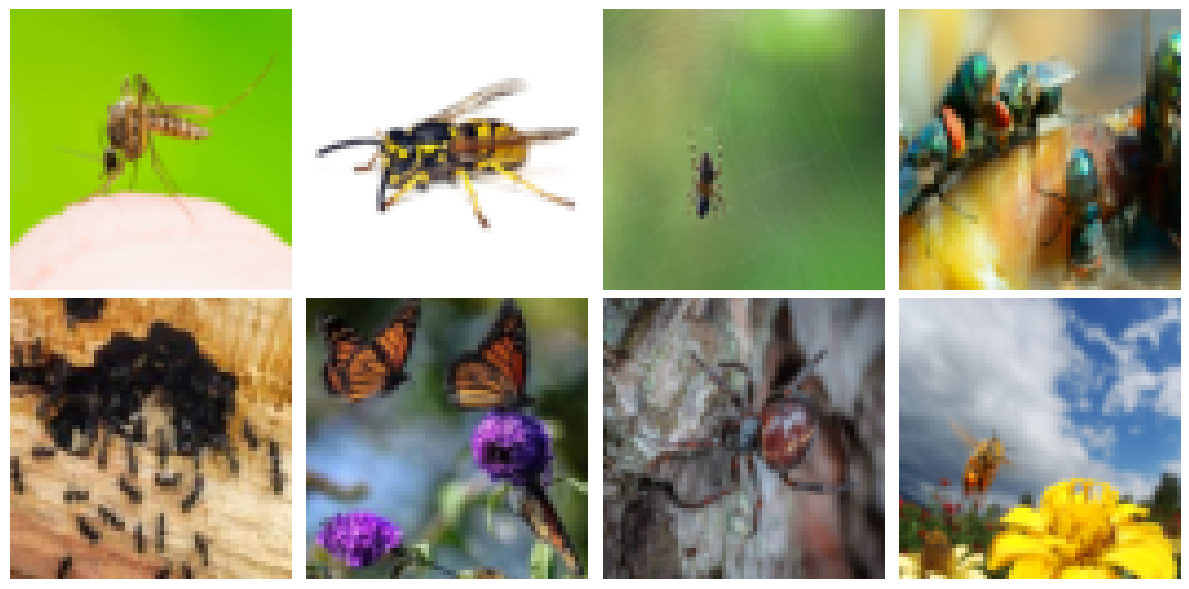

In [6]:
class InsectDataset(Dataset):
    """
    Custom dataset for loading insect images.
    Images are organized in subdirectories by insect type.
    """
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.insect_labels = []  # Track insect type for each image
        
        # Collect all image files from subdirectories
        for subdir in os.listdir(root_dir):
            subdir_path = os.path.join(root_dir, subdir)
            if os.path.isdir(subdir_path):
                for filename in os.listdir(subdir_path):
                    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                        self.image_paths.append(os.path.join(subdir_path, filename))
                        self.insect_labels.append(subdir)  # Store insect type
        
        print(f"Found {len(self.image_paths)} images")
        print(f"Insect categories: {sorted(set(self.insect_labels))}")
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        insect_label = self.insect_labels[idx]
        img_path = self.image_paths[idx]
        
        # Load image
        try:
            # Open image and convert to RGB (fixes palette/transparency warnings)
            try:
                with Image.open(img_path) as img:
                    # Convert palette images to RGB
                    if img.mode in ('P', 'RGBA', 'LA'):
                        img = img.convert('RGB')
                    elif img.mode != 'RGB':
                        img = img.convert('RGB')
                    image = img.copy()
        except Exception as e:
            # If image is corrupted, return a random other image
            return self.__getitem__(random.randint(0, len(self.image_paths) - 1))
        
        # Apply transformations
        if self.transform:
            image = self.transform(image)
        
        return image, insect_label

# Define image transformations
# Normalize to [-1, 1] range as recommended for GANs
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),  # Data augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # [-1, 1]
])

# Create dataset and dataloader
# pin_memory=True speeds up data transfer to GPU
dataset = InsectDataset(root_dir='data', transform=transform)
dataloader = DataLoader(
    dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=4, 
    pin_memory=True if torch.cuda.is_available() else False
)

# Visualize a sample batch
    def get_label(self, idx):
        """Get insect label for a given index"""
        return self.insect_labels[idx]
def show_samples(dataloader, num_samples=8, title="Sample Images from Dataset"):
    """Display a grid of sample images from the dataset"""
    dataiter = iter(dataloader)
    batch = next(dataiter)
    
    # Handle both (images, labels) and just images
    if isinstance(batch, tuple):
        images, labels = batch
    else:
        images = batch
        labels = ['Unknown'] * len(images)
    
    # Denormalize for display
    images = (images + 1) / 2.0  # Convert from [-1, 1] to [0, 1]
    images = torch.clamp(images, 0, 1)
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))  # Larger for better visibility
    axes = axes.flatten()
    for i in range(min(num_samples, len(images))):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        axes[i].imshow(img, interpolation='bilinear')
        label = labels[i] if isinstance(labels, (list, tuple)) else (labels[i].item() if hasattr(labels[i], 'item') else str(labels[i]))
        axes[i].set_title(f"{label}", fontsize=12, fontweight='bold')
        axes[i].axis('off')
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("Sample images from dataset:")
show_samples(dataloader)



## 3. Generator Network

The Generator uses **transposed convolutions** (also called deconvolutions) to upsample from a noise vector to a full image.

### Architecture:
- Input: Noise vector z of dimension 100
- Process: 
  1. Project to 4x4 feature maps with 512 channels
  2. Upsample through transposed convolutions: 4→8→16→32→64
  3. Each layer doubles spatial dimensions
- Output: 64×64×3 RGB image

### Key Components:
- **Transposed Convolution**: Upsamples by learning to "unfold" feature maps
- **Batch Normalization**: Stabilizes training by normalizing activations
- **ReLU**: Activation function (except last layer uses Tanh to output [-1, 1])

### Mathematical Operation:
For transposed convolution with stride s and padding p:
$$H_{out} = (H_{in} - 1) \times s - 2p + k$$

Where k is kernel size.


In [7]:
class Generator(nn.Module):
    """
    DCGAN Generator Network
    
    Architecture:
    - Input: Noise vector (NOISE_DIM,)
    - Output: RGB image (3, IMAGE_SIZE, IMAGE_SIZE)
    """
    def __init__(self, noise_dim=100, ngf=64):
        super(Generator, self).__init__()
        self.noise_dim = noise_dim
        self.ngf = ngf  # Number of generator filters
        
        # Project noise to 4x4 feature maps
        self.fc = nn.Linear(noise_dim, 4 * 4 * ngf * 8)
        
        # Transposed convolution layers
        self.conv_layers = nn.Sequential(
            # Input: (ngf*8) x 4 x 4
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # State: (ngf*4) x 8 x 8
            
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # State: (ngf*2) x 16 x 16
            
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # State: (ngf) x 32 x 32
            
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh()  # Output in [-1, 1]
            # Output: 3 x 64 x 64
        )
    
    def forward(self, z):
        """
        Forward pass
        
        Args:
            z: Noise tensor of shape (batch_size, noise_dim)
        
        Returns:
            Generated image tensor of shape (batch_size, 3, IMAGE_SIZE, IMAGE_SIZE)
        """
        # Project and reshape
        x = self.fc(z)
        x = x.view(x.size(0), self.ngf * 8, 4, 4)
        
        # Generate image through transposed convolutions
        x = self.conv_layers(x)
        return x

# Initialize generator
netG = Generator(noise_dim=NOISE_DIM, ngf=64).to(device)
print("Generator architecture:")
print(netG)

# Test generator with random noise
test_noise = torch.randn(1, NOISE_DIM, device=device)
test_output = netG(test_noise)
print(f"\nGenerator output shape: {test_output.shape}")
print(f"Expected shape: (1, 3, {IMAGE_SIZE}, {IMAGE_SIZE})")


Generator architecture:
Generator(
  (fc): Linear(in_features=100, out_features=8192, bias=True)
  (conv_layers): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)

Generator output shape: torch.Size([1, 3, 64, 64])
Expected shape: (1, 3, 64, 64)


## 4. Discriminator Network

The Discriminator (also called Critic in WGAN) uses **strided convolutions** to downsample the image and classify it as real or fake.

### Architecture:
- Input: 64×64×3 RGB image
- Process: Downsample through convolutions: 64→32→16→8→4
- Output: Single scalar (real/fake score)

### Key Components:
- **Strided Convolution**: Downsamples by using stride > 1
- **LeakyReLU**: Allows small negative gradients (prevents dead neurons)
- **No BatchNorm in first layer**: Common practice in DCGAN
- **No sigmoid**: WGAN uses raw scores, not probabilities

### Mathematical Operation:
For strided convolution with stride s:
$$H_{out} = \lfloor \frac{H_{in} + 2p - k}{s} \rfloor + 1$$


In [8]:
class Discriminator(nn.Module):
    """
    DCGAN Discriminator (Critic) Network
    
    Architecture:
    - Input: RGB image (3, IMAGE_SIZE, IMAGE_SIZE)
    - Output: Scalar score (real/fake)
    """
    def __init__(self, ndf=64):
        super(Discriminator, self).__init__()
        self.ndf = ndf  # Number of discriminator filters
        
        self.conv_layers = nn.Sequential(
            # Input: 3 x 64 x 64
            nn.Conv2d(3, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # State: (ndf) x 32 x 32
            
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # State: (ndf*2) x 16 x 16
            
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # State: (ndf*4) x 8 x 8
            
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # State: (ndf*8) x 4 x 4
            
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False)
            # Output: 1 x 1 x 1 (single scalar)
        )
    
    def forward(self, x):
        """
        Forward pass
        
        Args:
            x: Image tensor of shape (batch_size, 3, IMAGE_SIZE, IMAGE_SIZE)
        
        Returns:
            Score tensor of shape (batch_size, 1)
        """
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  # Flatten to (batch_size, 1)
        return x

# Initialize discriminator
netD = Discriminator(ndf=64).to(device)
print("Discriminator architecture:")
print(netD)

# Test discriminator with random image
test_image = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)
test_score = netD(test_image)
print(f"\nDiscriminator output shape: {test_score.shape}")
print(f"Expected shape: (1, 1)")


Discriminator architecture:
Discriminator(
  (conv_layers): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
  )
)

Discriminator 

## 5. Gradient Penalty Function

The gradient penalty is a key component of WGAN-GP. It enforces the Lipschitz constraint by penalizing gradients that deviate from 1.

### Mathematical Formulation:
The gradient penalty term is:
$$GP = \lambda \mathbb{E}_{\hat{x} \sim p_{\hat{x}}}[(\|\nabla_{\hat{x}} D(\hat{x})\|_2 - 1)^2]$$

Where:
- $\hat{x} = \epsilon x_{real} + (1-\epsilon) x_{fake}$ (random interpolation)
- $\lambda$ is the penalty coefficient (typically 10)
- We compute gradients with respect to the interpolated samples

This ensures the discriminator is 1-Lipschitz continuous, which is required for Wasserstein distance.

### Device Management:
All tensors in this function are explicitly placed on the same device (GPU/CPU) to avoid device mismatch errors:
- Input tensors are moved to device
- Random tensors are created on device
- Gradient computation tensors are on device


In [9]:
def compute_gradient_penalty(D, real_samples, fake_samples, device):
    """
    Compute gradient penalty for WGAN-GP
    
    Args:
        D: Discriminator network
        real_samples: Real images tensor
        fake_samples: Generated images tensor
        device: Computing device
    
    Returns:
        Gradient penalty scalar
    """
    # Ensure all tensors are on the same device
    real_samples = real_samples.to(device)
    fake_samples = fake_samples.to(device)
    
    # Random interpolation coefficient
    alpha = torch.rand(real_samples.size(0), 1, 1, 1, device=device, requires_grad=False)
    
    # Interpolate between real and fake samples
    interpolates = (alpha * real_samples + (1 - alpha) * fake_samples).requires_grad_(True)
    
    # Get discriminator output for interpolated samples
    d_interpolates = D(interpolates)
    
    # Compute gradients - ensure grad_outputs is on the same device
    grad_outputs = torch.ones(d_interpolates.size(), device=device, requires_grad=False)
    
    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=grad_outputs,
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]
    
    # Compute gradient penalty: (||grad||_2 - 1)^2
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    
    return gradient_penalty


## 6. Optimizers and Loss Functions

We use Adam optimizers for both networks. WGAN-GP doesn't use traditional loss functions but optimizes the Wasserstein distance directly.

### Discriminator Loss:
$$L_D = \mathbb{E}[D(x_{fake})] - \mathbb{E}[D(x_{real})] + \lambda \cdot GP$$

### Generator Loss:
$$L_G = -\mathbb{E}[D(x_{fake})]$$

Note: In WGAN, we maximize the discriminator's score on real data and minimize it on fake data. The generator tries to maximize the discriminator's score on its generated samples.


In [10]:
# Initialize optimizers
optimizerD = optim.Adam(netD.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))
optimizerG = optim.Adam(netG.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))

# Create directories for saving
os.makedirs('checkpoints', exist_ok=True)
os.makedirs('samples', exist_ok=True)

print("Optimizers initialized:")
print(f"Discriminator optimizer: Adam(lr={LEARNING_RATE}, betas=({BETA1}, {BETA2}))")
print(f"Generator optimizer: Adam(lr={LEARNING_RATE}, betas=({BETA1}, {BETA2}))")


Optimizers initialized:
Discriminator optimizer: Adam(lr=0.0002, betas=(0.5, 0.999))
Generator optimizer: Adam(lr=0.0002, betas=(0.5, 0.999))


## 7. Training Loop

The training process alternates between:
1. **Discriminator updates** (N_CRITIC times): Train discriminator to distinguish real from fake
2. **Generator update** (once): Train generator to fool the discriminator

### Training Steps:

**For each epoch:**
1. For each batch:
   - **Discriminator Training** (N_CRITIC iterations):
     - Sample real images
     - Generate fake images from noise
     - Compute discriminator loss with gradient penalty
     - Update discriminator
   
   - **Generator Training** (once):
     - Generate fake images from noise
     - Compute generator loss
     - Update generator

2. Save checkpoints periodically
3. Generate sample images to monitor progress

### Key Training Details:
- **N_CRITIC**: Number of discriminator updates per generator update (typically 5)
- **Gradient Penalty**: Computed on interpolated samples
- **Weight Clipping**: Not needed in WGAN-GP (gradient penalty replaces it)
- **Device Management**: All tensors (noise, images, gradients) are explicitly placed on the same device (GPU) for efficient training


In [11]:
# Fixed noise for generating consistent samples during training
# Ensure it's on the correct device
fixed_noise = torch.randn(64, NOISE_DIM, device=device, dtype=torch.float32)

# Training statistics
G_losses = []
D_losses = []

def save_checkpoint(epoch, netG, netD, optimizerG, optimizerD, losses):
    """Save model checkpoint"""
    checkpoint = {
        'epoch': epoch,
        'netG_state_dict': netG.state_dict(),
        'netD_state_dict': netD.state_dict(),
        'optimizerG_state_dict': optimizerG.state_dict(),
        'optimizerD_state_dict': optimizerD.state_dict(),
        'G_losses': losses[0],
        'D_losses': losses[1]
    }
    torch.save(checkpoint, f'checkpoints/checkpoint_epoch_{epoch}.pth')
    print(f"Checkpoint saved at epoch {epoch}")

def generate_samples(netG, noise, num_samples=16, save_path=None):
    """Generate and display sample images"""
    # Ensure noise is on the same device as the model
    noise = noise.to(next(netG.parameters()).device)
    
    netG.eval()
    with torch.no_grad():
        fake_images = netG(noise[:num_samples])
        fake_images = (fake_images + 1) / 2.0  # Denormalize to [0, 1]
        fake_images = torch.clamp(fake_images, 0, 1)
    
    netG.train()
    
    # Create grid of images
    fig, axes = plt.subplots(4, 4, figsize=(16, 16))  # Larger for better visibility
    axes = axes.flatten()
    for i in range(num_samples):
        # Move to CPU for visualization
        img = fake_images[i].permute(1, 2, 0).cpu().numpy()
        axes[i].imshow(img, interpolation='bilinear')
        axes[i].set_title(f"Generated {i+1}", fontsize=10, fontweight='bold')
        axes[i].axis('off')
    plt.suptitle("Generated Insect Images", fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
    plt.show()

print("Training utilities initialized")
print(f"Fixed noise shape for sampling: {fixed_noise.shape}")
print(f"Fixed noise device: {fixed_noise.device}")


Training utilities initialized
Fixed noise shape for sampling: torch.Size([64, 100])
Fixed noise device: cuda:0


Starting training...
Total epochs: 100
Batch size: 64
Discriminator updates per generator update: 5
Gradient penalty coefficient: 10
Device: cuda
--------------------------------------------------


Epoch 1/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 1/100:  30%|██▉       | 38/128 [00:08<00:17,  5.23it/s, D_loss=-487.7935, G_loss=245.6885, GP=0.1873]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 1/100:  30%|██▉       | 38/128 [00:08<00:17,  5.23it/s, D_los


Epoch [1/100]
  Discriminator Loss: -861.2596
  Generator Loss: 441.9192
--------------------------------------------------


Epoch 2/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 2/100:   2%|▏         | 3/128 [00:01<00:35,  3.50it/s, D_loss=-1587.2490, G_loss=941.1848, GP=22.8859]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 2/100:  23%|██▎       | 29/128 [00:05<00:17,  5.67it/s, D_loss=-2331.1799, G_loss=1173.5208, GP=0.4593] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
Epoch 2/100:  55%|█████▍    | 70/128 [00:14<00:11,  5.07it/s, D_loss=-2295.0144, G_loss=1401.2432, GP=14.3754]/home/2024032/oaqebl01/.local/lib/python3


Epoch [2/100]
  Discriminator Loss: -2263.9816
  Generator Loss: 1372.3932
--------------------------------------------------


...


Epoch [3/100]
  Discriminator Loss: -4192.0744
  Generator Loss: 2585.4191
--------------------------------------------------


Epoch 4/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 4/100:  11%|█         | 14/128 [00:03<00:27,  4.12it/s, D_loss=-6748.0298, G_loss=3676.8047, GP=63.6155]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 4/100:  23%|██▎       | 30/128 [00:05<00:18,  5.21it/s, D_loss=-7440.2563, G_loss=3923.0508, GP=36.1999]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes 


Epoch [4/100]
  Discriminator Loss: -7248.6212
  Generator Loss: 4369.9149
--------------------------------------------------


Epoch 5/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 5/100:  14%|█▍        | 18/128 [00:03<00:16,  6.57it/s, D_loss=-2954.4922, G_loss=4124.3188, GP=59.3975] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 5/100:  26%|██▌       | 33/128 [00:06<00:15,  6.03it/s, D_loss=-4836.2852, G_loss=4874.8188, GP=88.5997] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 5/100:  45%|████▍     | 57/128 [00:10<00:11,  6.17it/s, D_loss=-1658.0659, G_loss=4547.5234, GP=31.7327] /home/2024032/oaqebl01/.local/


Epoch [5/100]
  Discriminator Loss: -3775.1929
  Generator Loss: 5016.6772
  Generating samples...


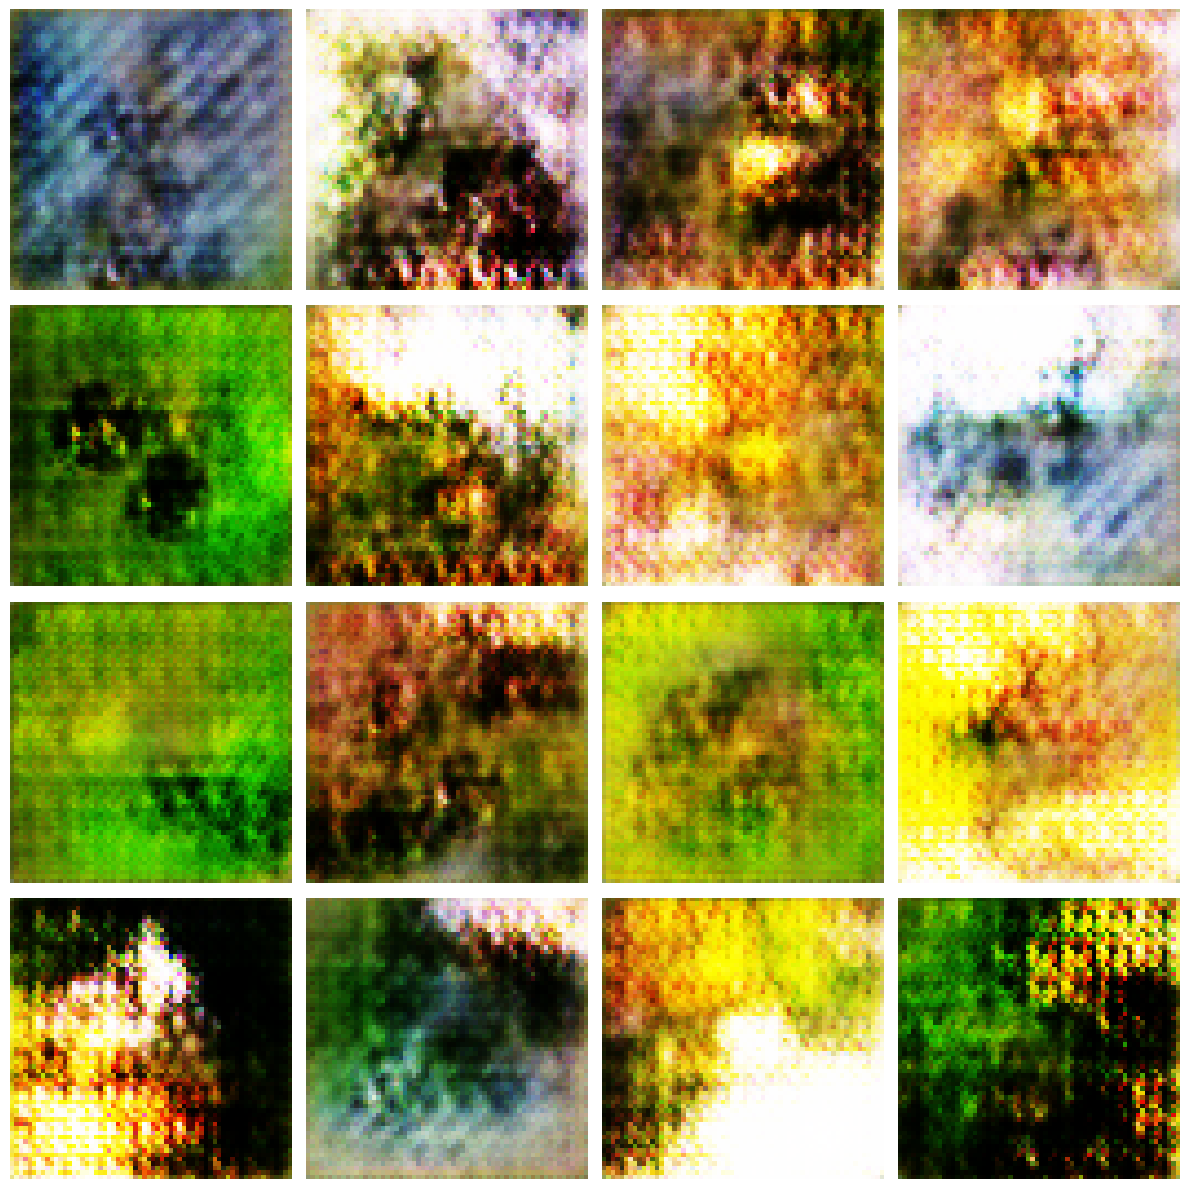

--------------------------------------------------


Epoch 6/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 6/100:   6%|▋         | 8/128 [00:02<00:21,  5.49it/s, D_loss=-3971.7920, G_loss=5267.4844, GP=118.5207]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 6/100:   9%|▉         | 12/128 [00:02<00:17,  6.53it/s, D_loss=-4643.0684, G_loss=5124.4448, GP=96.0584] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 6/100:  34%|███▎      | 43/128 [00:08<00:13,  6.49it/s, D_loss=-5412.0439, G_loss=5434.5303, GP=149.5179]/home/2024032/oaqebl01/.local/l


Epoch [6/100]
  Discriminator Loss: -4398.3326
  Generator Loss: 5455.5543
--------------------------------------------------


Epoch 7/100:   4%|▍         | 5/128 [00:01<00:42,  2.89it/s, D_loss=-5378.0684, G_loss=5914.7148, GP=84.9492]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 7/100:  46%|████▌     | 59/128 [00:10<00:12,  5.64it/s, D_loss=-6083.6191, G_loss=6234.8335, GP=145.1208]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
Epoch 7/100:  48%|████▊     | 62/128 [00:11<00:16,  3.88it/s, D_loss=-6318.6992, G_loss=6130.1743, GP=111.1199]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 7/100:  71%|███████   | 91/128 [00:16<00:07,  4.64it/s, D_loss=-1029.9177, G_loss=57


Epoch [7/100]
  Discriminator Loss: -3322.4166
  Generator Loss: 5886.4828
--------------------------------------------------


...


Epoch [8/100]
  Discriminator Loss: -3083.7325
  Generator Loss: 6229.8563
--------------------------------------------------


Epoch 9/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 9/100:   1%|          | 1/128 [00:00<01:21,  1.55it/s, D_loss=-2362.2283, G_loss=5560.3901, GP=88.8254]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 9/100:   8%|▊         | 10/128 [00:02<00:18,  6.32it/s, D_loss=-3217.4668, G_loss=5886.2788, GP=77.4581]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 9/100:  19%|█▉        | 24/128 [00:04<00:14,  7.13it/s, D_loss=-2683.3210, G_loss=5768.6406, GP=54.3763] /home/2024032/oaqebl01/.local/lib


Epoch [9/100]
  Discriminator Loss: -1976.9825
  Generator Loss: 5975.6217
--------------------------------------------------


Epoch 10/100:   3%|▎         | 4/128 [00:01<00:27,  4.49it/s, D_loss=-2160.8110, G_loss=6147.4043, GP=75.6989]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 10/100:   4%|▍         | 5/128 [00:01<00:35,  3.49it/s, D_loss=-2067.9561, G_loss=5905.2754, GP=46.2324]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 10/100:   6%|▋         | 8/128 [00:02<00:29,  4.05it/s, D_loss=-2322.4238, G_loss=5893.4648, GP=78.2598]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 10/100:  12%|█▎        | 16/128 [00:04<00:24,  4.55it/s, D_loss=-2026.9910, G_l


Epoch [10/100]
  Discriminator Loss: -2776.0476
  Generator Loss: 6399.7182
  Generating samples...


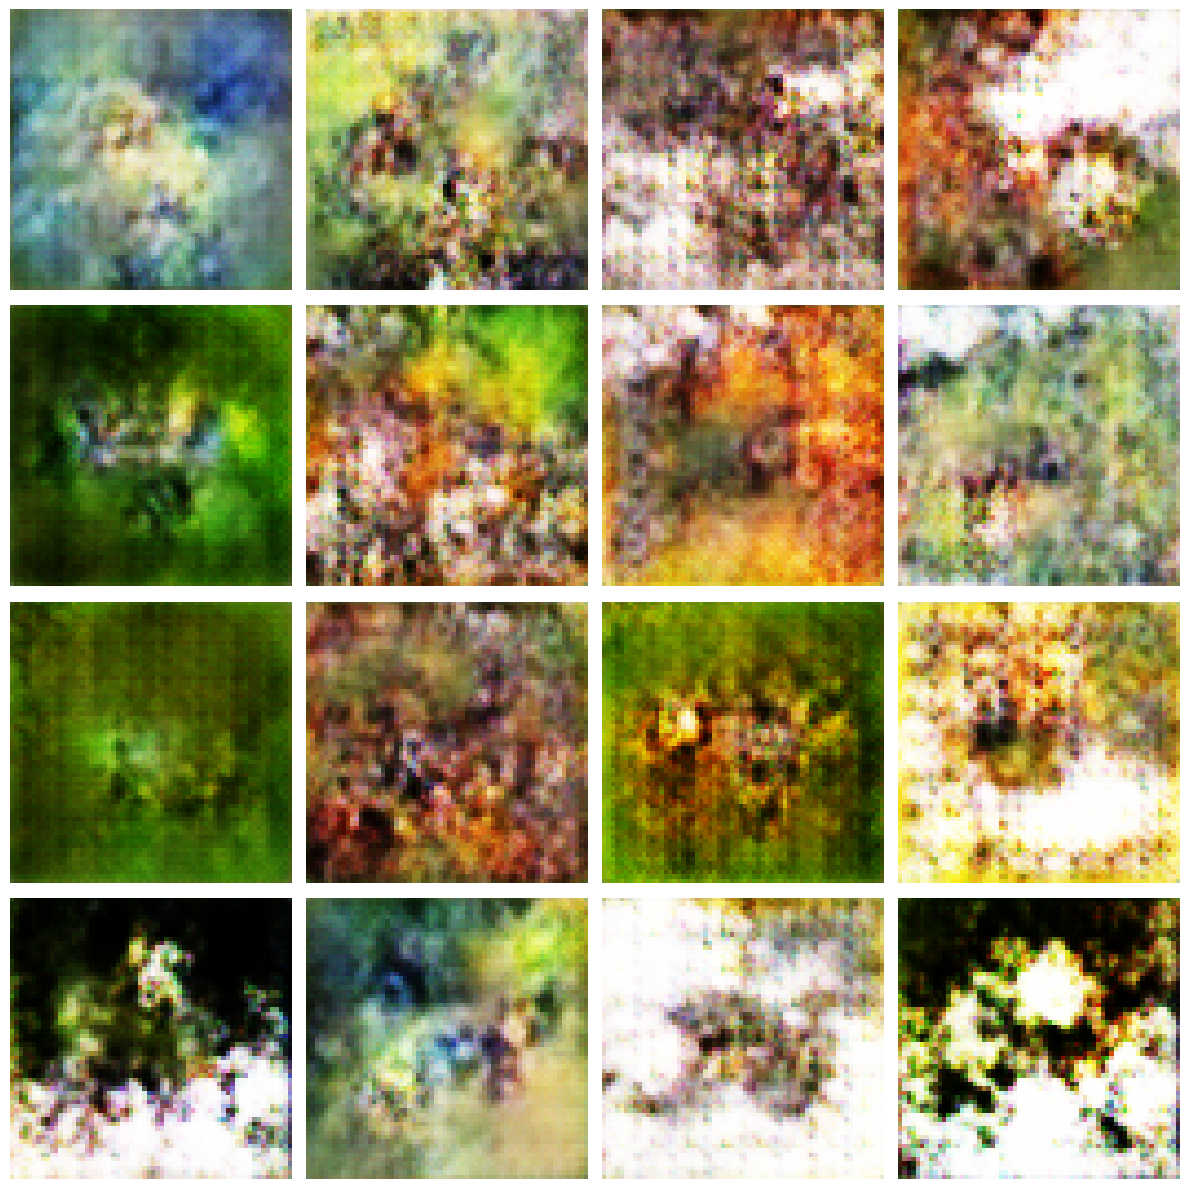

Checkpoint saved at epoch 10
--------------------------------------------------


Epoch 11/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 11/100:  10%|█         | 13/128 [00:03<00:27,  4.16it/s, D_loss=-4535.3481, G_loss=5796.0322, GP=101.3063]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 11/100:  13%|█▎        | 17/128 [00:03<00:19,  5.57it/s, D_loss=-3834.7026, G_loss=7240.2461, GP=83.1649] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 11/100:  38%|███▊      | 49/128 [00:10<00:19,  4.01it/s, D_loss=-3999.9834, G_loss=5611.6719, GP=162.5718]/home/2024032/oaqebl01/.lo


Epoch [11/100]
  Discriminator Loss: -2933.5729
  Generator Loss: 6925.2459
--------------------------------------------------


Epoch 12/100:   4%|▍         | 5/128 [00:01<00:28,  4.37it/s, D_loss=-1146.4849, G_loss=7215.8311, GP=49.1120]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 12/100:   7%|▋         | 9/128 [00:02<00:21,  5.51it/s, D_loss=-1399.7056, G_loss=7029.2393, GP=49.1184]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 12/100:  19%|█▉        | 24/128 [00:04<00:18,  5.75it/s, D_loss=-1767.2847, G_loss=6642.0059, GP=46.5707]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 12/100:  33%|███▎      | 42/128 [00:08<00:19,  4.50it/s, D_loss=-7018.7002, G_


Epoch [12/100]
  Discriminator Loss: -1526.3981
  Generator Loss: 6847.8866
--------------------------------------------------


...


Epoch [13/100]
  Discriminator Loss: -2548.0941
  Generator Loss: 7763.0941
--------------------------------------------------


Epoch 14/100:   3%|▎         | 4/128 [00:01<00:40,  3.05it/s, D_loss=-1523.1355, G_loss=7357.2573, GP=38.6958]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 14/100:  24%|██▍       | 31/128 [00:06<00:16,  6.05it/s, D_loss=-2126.1436, G_loss=7487.2764, GP=51.6092]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 14/100:  29%|██▉       | 37/128 [00:06<00:13,  6.78it/s, D_loss=-2224.3901, G_loss=7399.5166, GP=40.9945] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 14/100:  30%|██▉       | 38/128 [00:07<00:17,  5.04it/s, D_loss=-2849.4976, 


Epoch [14/100]
  Discriminator Loss: -2910.5039
  Generator Loss: 7931.8970
--------------------------------------------------


Epoch 15/100:  27%|██▋       | 35/128 [00:06<00:12,  7.39it/s, D_loss=-12312.2256, G_loss=8512.5859, GP=88.5926]  /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 15/100:  42%|████▏     | 54/128 [00:10<00:10,  6.96it/s, D_loss=154.9153, G_loss=10190.5186, GP=34.0861]    /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 15/100:  50%|█████     | 64/128 [00:12<00:20,  3.14it/s, D_loss=-607.1019, G_loss=8452.6191, GP=18.7179]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 15/100:  66%|██████▋   | 85/128 [00:16<00:07,  6.07it/s, D_loss=-1990.2


Epoch [15/100]
  Discriminator Loss: -3838.7159
  Generator Loss: 9516.9511
  Generating samples...


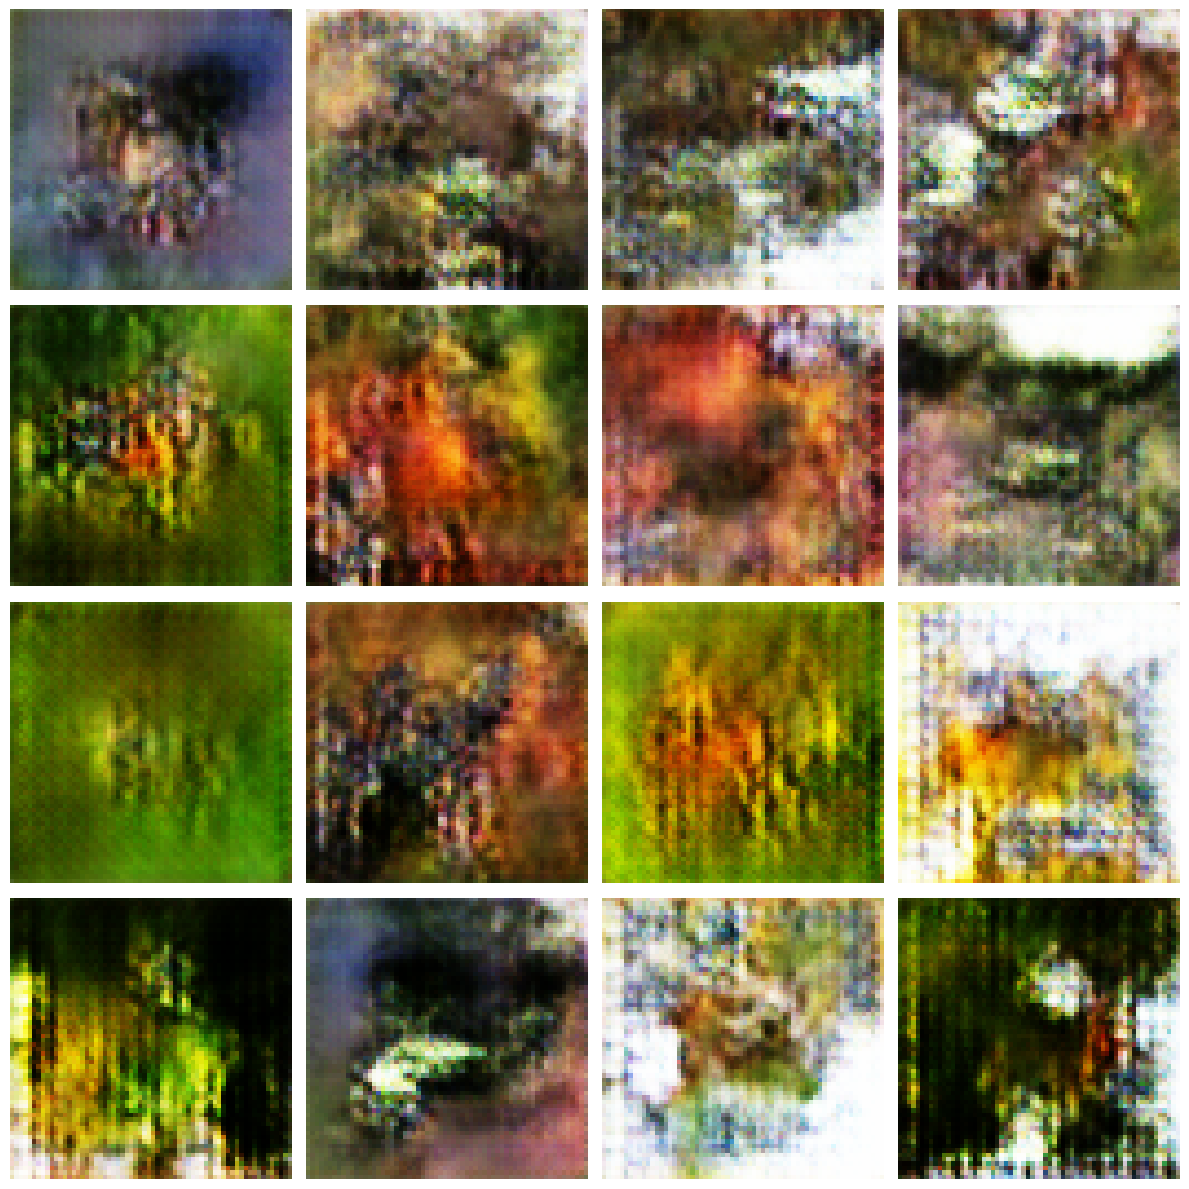

--------------------------------------------------


Epoch 16/100:   2%|▏         | 2/128 [00:00<00:54,  2.32it/s, D_loss=-4626.3623, G_loss=9639.8516, GP=82.6956]  /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 16/100:  24%|██▍       | 31/128 [00:05<00:18,  5.36it/s, D_loss=-6931.9766, G_loss=12070.1055, GP=218.3732] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 16/100:  34%|███▍      | 44/128 [00:08<00:18,  4.58it/s, D_loss=-7921.2817, G_loss=6778.2183, GP=236.9279] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 16/100:  50%|█████     | 64/128 [00:11<00:10,  6.00it/s, D_loss=-17380


Epoch [16/100]
  Discriminator Loss: -5075.8163
  Generator Loss: 11109.8364
--------------------------------------------------


Epoch 17/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 17/100:   7%|▋         | 9/128 [00:02<00:22,  5.31it/s, D_loss=62.3228, G_loss=9844.5312, GP=4.9898]     /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 17/100:   9%|▊         | 11/128 [00:02<00:25,  4.58it/s, D_loss=-68.4266, G_loss=10074.5186, GP=3.9159]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 17/100:  16%|█▋        | 21/128 [00:04<00:19,  5.46it/s, D_loss=233.3035, G_loss=9579.1367, GP=4.1497] /home/2024032/oaqebl01/.local/lib


Epoch [17/100]
  Discriminator Loss: -273.9721
  Generator Loss: 9751.1627
--------------------------------------------------


...


Epoch [18/100]
  Discriminator Loss: -728.6641
  Generator Loss: 9791.9639
--------------------------------------------------


Epoch 19/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 19/100:   1%|          | 1/128 [00:01<02:21,  1.12s/it, D_loss=-1228.8840, G_loss=9719.0498, GP=28.2632]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 19/100:  19%|█▉        | 24/128 [00:04<00:13,  7.86it/s, D_loss=-1257.4236, G_loss=10718.6406, GP=34.2502]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in byt


Epoch [19/100]
  Discriminator Loss: -1263.2302
  Generator Loss: 10186.6663
--------------------------------------------------


Epoch 20/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 20/100:   2%|▏         | 2/128 [00:00<00:43,  2.92it/s, D_loss=-1856.0532, G_loss=11258.0225, GP=108.2467]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 20/100:   8%|▊         | 10/128 [00:02<00:22,  5.25it/s, D_loss=-2268.5955, G_loss=10847.9941, GP=47.5217]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 20/100:  32%|███▏      | 41/128 [00:07<00:13,  6.23it/s, D_loss=-3491.6545, G_loss=11876.3623, GP=63.9505]/home/2024032/oaqebl01/.lo


Epoch [20/100]
  Discriminator Loss: -2491.9782
  Generator Loss: 11313.1188
  Generating samples...


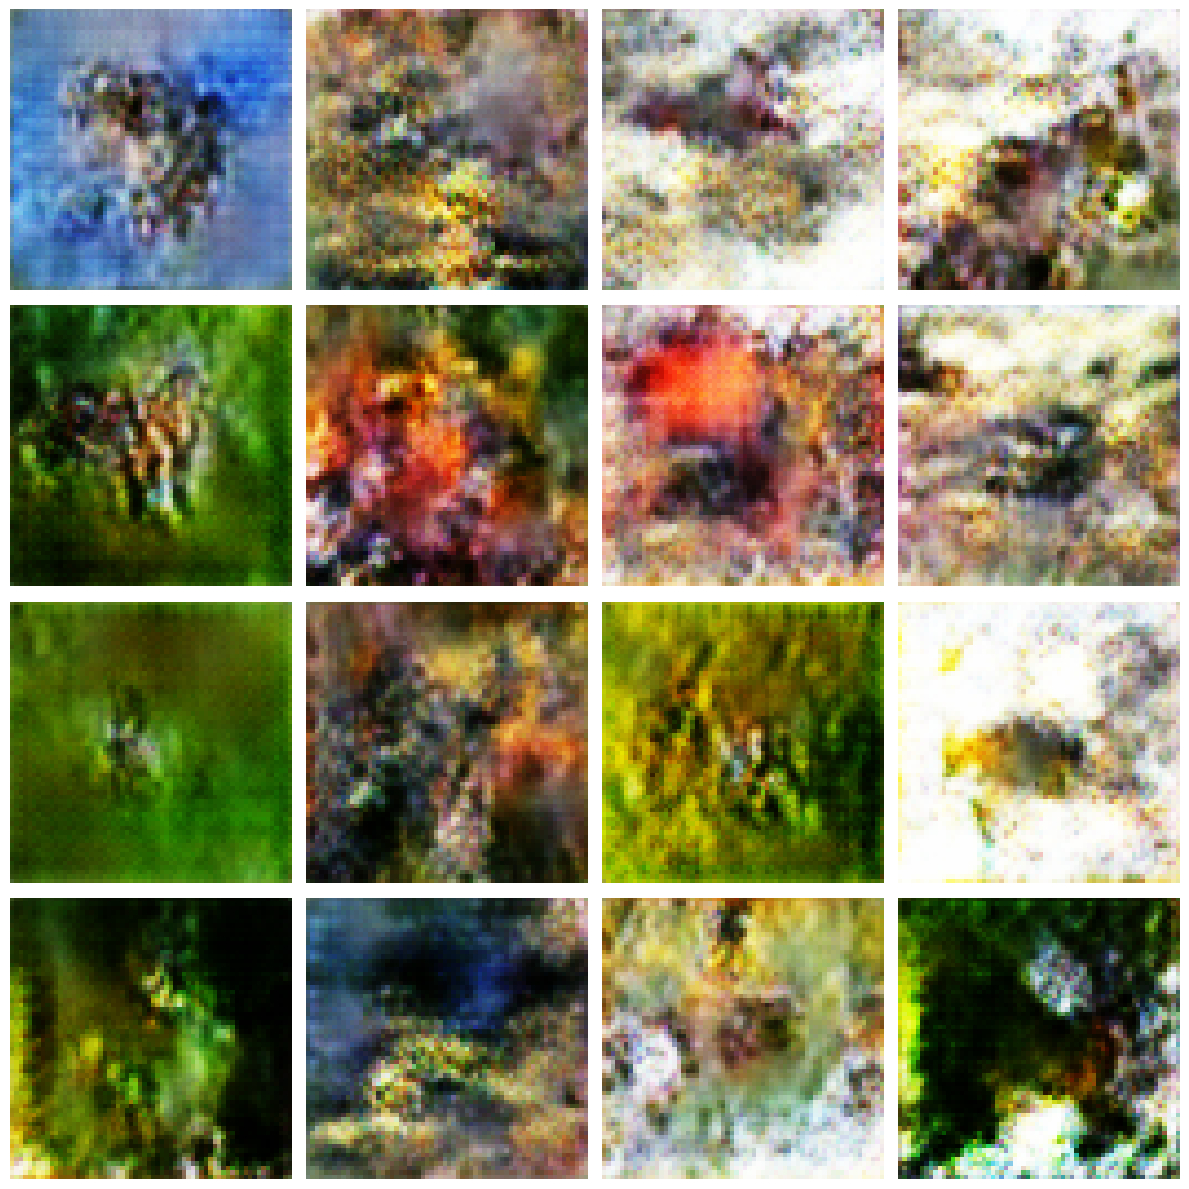

Checkpoint saved at epoch 20
--------------------------------------------------


Epoch 21/100:   3%|▎         | 4/128 [00:01<00:25,  4.83it/s, D_loss=-5135.4541, G_loss=12864.0811, GP=42.5411] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 21/100:   9%|▊         | 11/128 [00:02<00:19,  5.91it/s, D_loss=-4681.3613, G_loss=11703.9102, GP=110.2879]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 21/100:  25%|██▌       | 32/128 [00:06<00:13,  6.90it/s, D_loss=-5567.6436, G_loss=12893.8652, GP=57.9912] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
Epoch 21/100:  28%|██▊       | 36/128 [00:06<00:12,  7.22it/s, D_loss=-6256.8018, G


Epoch [21/100]
  Discriminator Loss: -4245.2239
  Generator Loss: 12413.5149
--------------------------------------------------


Epoch 22/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 22/100:   2%|▏         | 3/128 [00:01<00:39,  3.19it/s, D_loss=-162.6679, G_loss=11492.0684, GP=5.4379]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 22/100:   3%|▎         | 4/128 [00:01<00:30,  4.04it/s, D_loss=-21.2899, G_loss=11534.7920, GP=5.0351] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
Epoch 22/100:  12%|█▎        | 16/128 [00:04<00:18,  5.94it/s, D_loss=-139.0058, G_loss=11515.5615, GP=7.3143]/home/2024032/oaqebl01/.local/lib/python


Epoch [22/100]
  Discriminator Loss: -595.3217
  Generator Loss: 11381.7084
--------------------------------------------------


...


Epoch [23/100]
  Discriminator Loss: -2474.0682
  Generator Loss: 12006.7909
--------------------------------------------------


Epoch 24/100:   6%|▋         | 8/128 [00:01<00:15,  7.53it/s, D_loss=-5981.9019, G_loss=14948.7471, GP=64.9790]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 24/100:  18%|█▊        | 23/128 [00:04<00:16,  6.26it/s, D_loss=-5682.6533, G_loss=13266.1865, GP=198.0849] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 24/100:  19%|█▉        | 24/128 [00:04<00:16,  6.49it/s, D_loss=-8984.1016, G_loss=9868.7793, GP=253.2861] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 24/100:  60%|██████    | 77/128 [00:14<00:07,  6.50it/s, D_loss=-2060.0


Epoch [24/100]
  Discriminator Loss: -1620.6959
  Generator Loss: 12016.4272
--------------------------------------------------


Epoch 25/100:   7%|▋         | 9/128 [00:01<00:18,  6.28it/s, D_loss=-1897.2582, G_loss=10097.7949, GP=91.6091] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 25/100:  17%|█▋        | 22/128 [00:04<00:15,  7.06it/s, D_loss=-8832.2373, G_loss=13257.0361, GP=154.3536]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 25/100:  33%|███▎      | 42/128 [00:07<00:14,  6.07it/s, D_loss=-602.8923, G_loss=6748.1509, GP=22.1385]   /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 25/100:  41%|████▏     | 53/128 [00:09<00:12,  5.94it/s, D_loss=-636.19


Epoch [25/100]
  Discriminator Loss: -3996.3891
  Generator Loss: 12140.2355
  Generating samples...


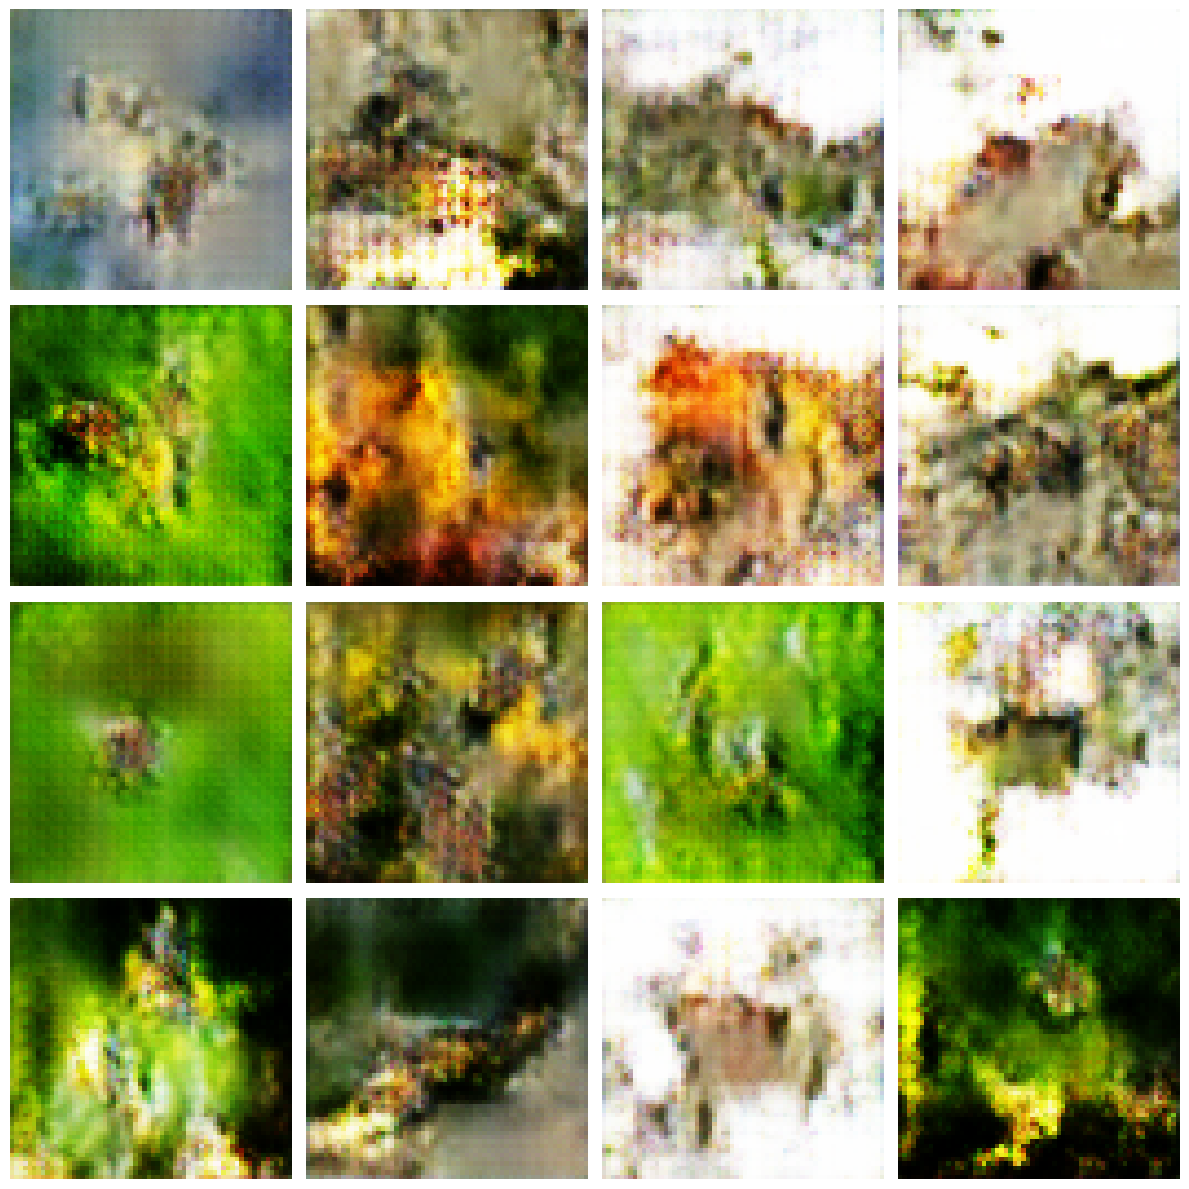

--------------------------------------------------


Epoch 26/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 26/100:   6%|▋         | 8/128 [00:02<00:20,  5.76it/s, D_loss=-15537.9863, G_loss=13951.3750, GP=332.6541]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 26/100:   9%|▊         | 11/128 [00:02<00:18,  6.42it/s, D_loss=-441.1452, G_loss=11023.4766, GP=15.0964]  /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 26/100:  38%|███▊      | 48/128 [00:09<00:13,  5.99it/s, D_loss=-2726.2510, G_loss=11087.5342, GP=81.5591] /home/2024032/oaqebl01/


Epoch [26/100]
  Discriminator Loss: -3072.6249
  Generator Loss: 11387.7345
--------------------------------------------------


Epoch 27/100:  10%|█         | 13/128 [00:02<00:19,  5.92it/s, D_loss=-10632.3799, G_loss=18939.1328, GP=79.7095]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 27/100:  17%|█▋        | 22/128 [00:04<00:14,  7.30it/s, D_loss=-13205.1094, G_loss=18171.4766, GP=120.9480]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 27/100:  20%|██        | 26/128 [00:05<00:18,  5.39it/s, D_loss=-6620.0283, G_loss=17167.2988, GP=1220.9073]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/TiffImagePl


Epoch [27/100]
  Discriminator Loss: -2558.9679
  Generator Loss: 10929.6196
--------------------------------------------------


...


Epoch [28/100]
  Discriminator Loss: -1413.7912
  Generator Loss: 11998.0409
--------------------------------------------------


Epoch 29/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 29/100:  12%|█▏        | 15/128 [00:03<00:19,  5.86it/s, D_loss=-784.7150, G_loss=11645.0586, GP=32.2446] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 29/100:  15%|█▍        | 19/128 [00:04<00:19,  5.57it/s, D_loss=-1447.9236, G_loss=11955.6602, GP=36.1186]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 29/100:  38%|███▊      | 48/128 [00:09<00:11,  6.99it/s, D_loss=-1133.9121, G_loss=12363.9707, GP=39.2017]/home/2024032/oaqebl01/.lo


Epoch [29/100]
  Discriminator Loss: -1342.8143
  Generator Loss: 12085.4102
--------------------------------------------------


Epoch 30/100:  15%|█▍        | 19/128 [00:03<00:14,  7.74it/s, D_loss=-3474.2319, G_loss=14516.2148, GP=71.3260] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 30/100:  26%|██▌       | 33/128 [00:06<00:16,  5.79it/s, D_loss=-1669.9324, G_loss=14074.4814, GP=40.6176] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 30/100:  38%|███▊      | 49/128 [00:09<00:13,  6.02it/s, D_loss=-3360.1689, G_loss=13846.6797, GP=108.2702]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 30/100:  50%|█████     | 64/128 [00:12<00:14,  4.47it/s, D_loss=-5119.


Epoch [30/100]
  Discriminator Loss: -3325.4788
  Generator Loss: 14067.4341
  Generating samples...


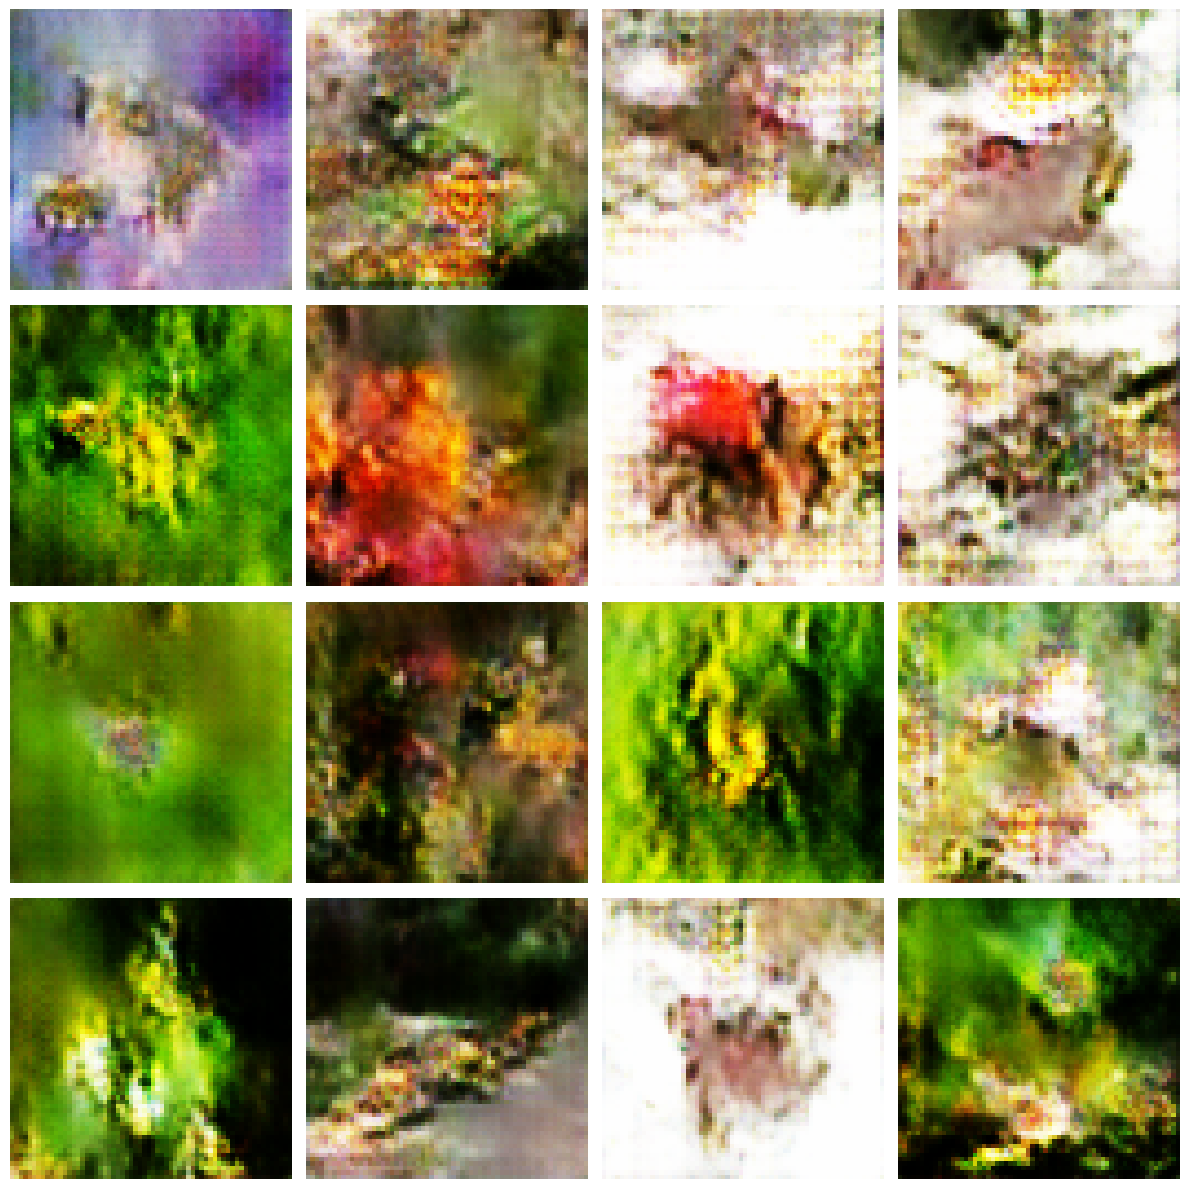

Checkpoint saved at epoch 30
--------------------------------------------------


Epoch 31/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 31/100:   7%|▋         | 9/128 [00:02<00:30,  3.88it/s, D_loss=-3687.0701, G_loss=16841.4629, GP=320.6128]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 31/100:  20%|█▉        | 25/128 [00:05<00:19,  5.38it/s, D_loss=-8474.0391, G_loss=14795.0215, GP=204.3196] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 31/100:  28%|██▊       | 36/128 [00:07<00:24,  3.81it/s, D_loss=-10611.9219, G_loss=20826.6484, GP=111.9238]/home/2024032/oaqebl01


Epoch [31/100]
  Discriminator Loss: -3458.4218
  Generator Loss: 13967.9741
--------------------------------------------------


Epoch 32/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
Epoch 32/100:  16%|█▌        | 20/128 [00:03<00:15,  7.00it/s, D_loss=-23889.2676, G_loss=14452.8750, GP=197.5453]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 32/100:  20%|█▉        | 25/128 [00:04<00:17,  6.05it/s, D_loss=-4333.1396, G_loss=17607.8379, GP=189.6115]  /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 32/100:  26%|██▌       | 33/128 [00:06<00:15,  6.28it/s, D_loss=-5910.7915, G_loss=20815.0156, GP=239.8974]/home/2024032/oaqebl01/.lo


Epoch [32/100]
  Discriminator Loss: -7600.2533
  Generator Loss: 16076.0945
--------------------------------------------------


...


Epoch [33/100]
  Discriminator Loss: -2083.2912
  Generator Loss: 13017.7374
--------------------------------------------------


Epoch 34/100:   2%|▏         | 2/128 [00:00<00:46,  2.70it/s, D_loss=-1709.0068, G_loss=11845.9512, GP=61.2769]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 34/100:   5%|▍         | 6/128 [00:01<00:21,  5.71it/s, D_loss=-943.3835, G_loss=11890.4873, GP=61.3419] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 34/100:   9%|▊         | 11/128 [00:02<00:17,  6.54it/s, D_loss=-1835.6917, G_loss=10508.4160, GP=71.6381]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 34/100:  13%|█▎        | 17/128 [00:03<00:20,  5.31it/s, D_loss=-2156.1746,


Epoch [34/100]
  Discriminator Loss: -2900.5661
  Generator Loss: 14295.9545
--------------------------------------------------


Epoch 35/100:   5%|▌         | 7/128 [00:01<00:21,  5.53it/s, D_loss=-21.2382, G_loss=14563.0723, GP=5.5558] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 35/100:  14%|█▍        | 18/128 [00:03<00:21,  5.12it/s, D_loss=49.9376, G_loss=14938.2148, GP=6.0219]  /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 35/100:  15%|█▍        | 19/128 [00:04<00:18,  5.79it/s, D_loss=-295.4561, G_loss=14791.5938, GP=7.6359]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 35/100:  21%|██        | 27/128 [00:05<00:16,  5.99it/s, D_loss=-107.0967, G_los


Epoch [35/100]
  Discriminator Loss: -373.0498
  Generator Loss: 14515.6457
  Generating samples...


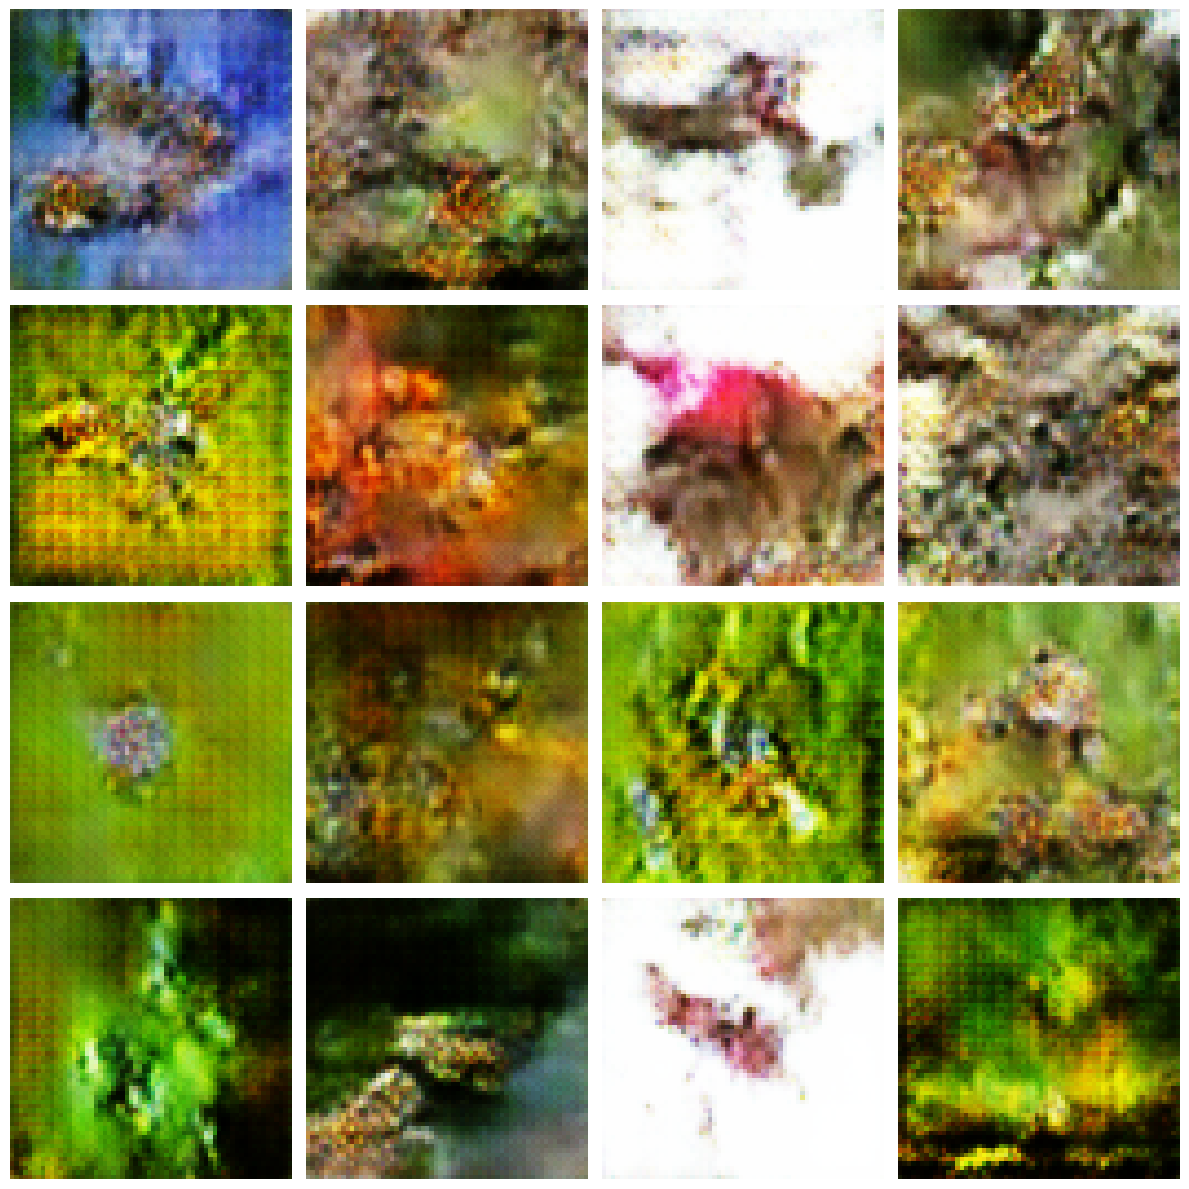

--------------------------------------------------


Epoch 36/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 36/100:  11%|█         | 14/128 [00:03<00:19,  5.89it/s, D_loss=-551.7250, G_loss=14515.3477, GP=24.7471]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 36/100:  12%|█▏        | 15/128 [00:03<00:18,  6.11it/s, D_loss=-992.9061, G_loss=14095.1270, GP=18.7677]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
Epoch 36/100:  28%|██▊       | 36/128 [00:07<00:17,  5.30it/s, D_loss=-546.3019, G_loss=14258.3457, GP=9.3032]  /home/2024032/oaqebl01/.local/lib/


Epoch [36/100]
  Discriminator Loss: -651.5663
  Generator Loss: 14189.9210
--------------------------------------------------


Epoch 37/100:   5%|▍         | 6/128 [00:01<00:22,  5.43it/s, D_loss=-822.6635, G_loss=12944.6816, GP=14.6623] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 37/100:  23%|██▎       | 29/128 [00:06<00:16,  5.98it/s, D_loss=-1351.3354, G_loss=15301.8193, GP=56.9076]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 37/100:  42%|████▏     | 54/128 [00:11<00:18,  3.92it/s, D_loss=-948.1917, G_loss=13036.8496, GP=29.3049] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 37/100:  45%|████▍     | 57/128 [00:11<00:11,  5.98it/s, D_loss=-864.6963,


Epoch [37/100]
  Discriminator Loss: -1307.6983
  Generator Loss: 14339.4121
--------------------------------------------------


...


Epoch [38/100]
  Discriminator Loss: -2023.6321
  Generator Loss: 15981.7150
--------------------------------------------------


Epoch 39/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 39/100:   1%|          | 1/128 [00:00<01:27,  1.44it/s, D_loss=-661.1648, G_loss=15606.4131, GP=28.8706]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
Epoch 39/100:  28%|██▊       | 36/128 [00:07<00:15,  5.90it/s, D_loss=-990.8730, G_loss=14843.5938, GP=34.3192]  /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 39/100:  45%|████▌     | 58/128 [00:10<00:11,  6.12it/s, D_loss=-4599.8315, G_loss=20001.0059, GP=113.4202]/home/2024032/oaqebl01/.local/li


Epoch [39/100]
  Discriminator Loss: -3796.6638
  Generator Loss: 19236.5911
--------------------------------------------------


Epoch 40/100:   3%|▎         | 4/128 [00:01<00:35,  3.53it/s, D_loss=-3431.7620, G_loss=19225.3867, GP=64.1405]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 40/100:   7%|▋         | 9/128 [00:02<00:19,  6.21it/s, D_loss=-6386.0645, G_loss=18201.2227, GP=192.6647]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 40/100:  11%|█         | 14/128 [00:03<00:24,  4.68it/s, D_loss=-7455.1479, G_loss=17800.7109, GP=167.6901]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 40/100:  55%|█████▌    | 71/128 [00:13<00:07,  7.21it/s, D_loss=-1513.371


Epoch [40/100]
  Discriminator Loss: -3722.7829
  Generator Loss: 18481.4958
  Generating samples...


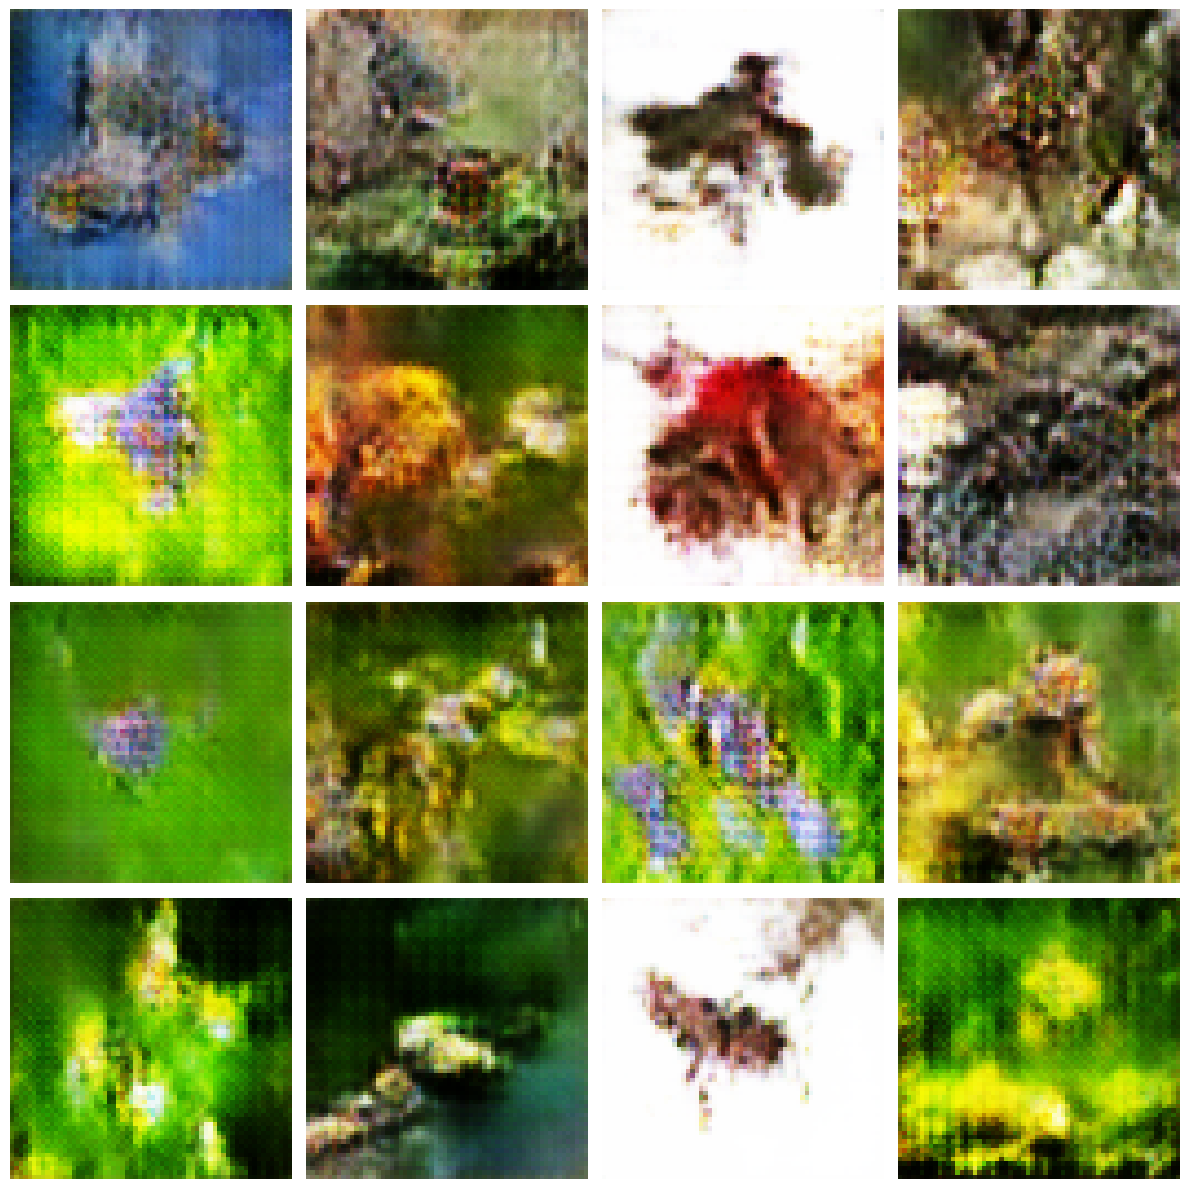

Checkpoint saved at epoch 40
--------------------------------------------------


Epoch 41/100:   4%|▍         | 5/128 [00:01<00:22,  5.50it/s, D_loss=-3123.5615, G_loss=21116.9102, GP=61.3796]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 41/100:   5%|▍         | 6/128 [00:01<00:21,  5.57it/s, D_loss=-3493.4780, G_loss=22048.3945, GP=70.8905]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 41/100:  37%|███▋      | 47/128 [00:09<00:09,  8.25it/s, D_loss=-1896.3812, G_loss=15462.9824, GP=31.4078] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarn


Epoch [41/100]
  Discriminator Loss: -1602.5214
  Generator Loss: 17308.5328
--------------------------------------------------


Epoch 42/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 42/100:  22%|██▏       | 28/128 [00:05<00:15,  6.48it/s, D_loss=-1515.6245, G_loss=13165.9160, GP=45.5798]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 42/100:  35%|███▌      | 45/128 [00:09<00:15,  5.51it/s, D_loss=-876.5001, G_loss=16406.1973, GP=49.5287] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 42/100:  59%|█████▉    | 76/128 [00:15<00:11,  4.41it/s, D_loss=-2237.1350, G_loss=19796.8184, GP=71.6273]/home/2024032/oaqebl01/.lo


Epoch [42/100]
  Discriminator Loss: -1486.8364
  Generator Loss: 16892.4821
--------------------------------------------------


...


Epoch [43/100]
  Discriminator Loss: -3943.3598
  Generator Loss: 19669.2302
--------------------------------------------------


Epoch 44/100:  10%|█         | 13/128 [00:02<00:20,  5.69it/s, D_loss=-3102.6155, G_loss=18108.5508, GP=64.3835] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 44/100:  17%|█▋        | 22/128 [00:04<00:18,  5.78it/s, D_loss=-6084.3423, G_loss=25124.7109, GP=76.5572] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 44/100:  19%|█▉        | 24/128 [00:04<00:15,  6.66it/s, D_loss=-985.6917, G_loss=15516.3027, GP=31.0863]  /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 44/100:  45%|████▌     | 58/128 [00:10<00:13,  5.13it/s, D_loss=-8836.


Epoch [44/100]
  Discriminator Loss: -2818.0591
  Generator Loss: 17540.0476
--------------------------------------------------


Epoch 45/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 45/100:   4%|▍         | 5/128 [00:01<00:26,  4.72it/s, D_loss=-465.0303, G_loss=14619.5645, GP=14.7436]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 45/100:  30%|██▉       | 38/128 [00:07<00:13,  6.56it/s, D_loss=-601.0928, G_loss=15155.9082, GP=27.9190] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in byt


Epoch [45/100]
  Discriminator Loss: -1094.9381
  Generator Loss: 14906.5254
  Generating samples...


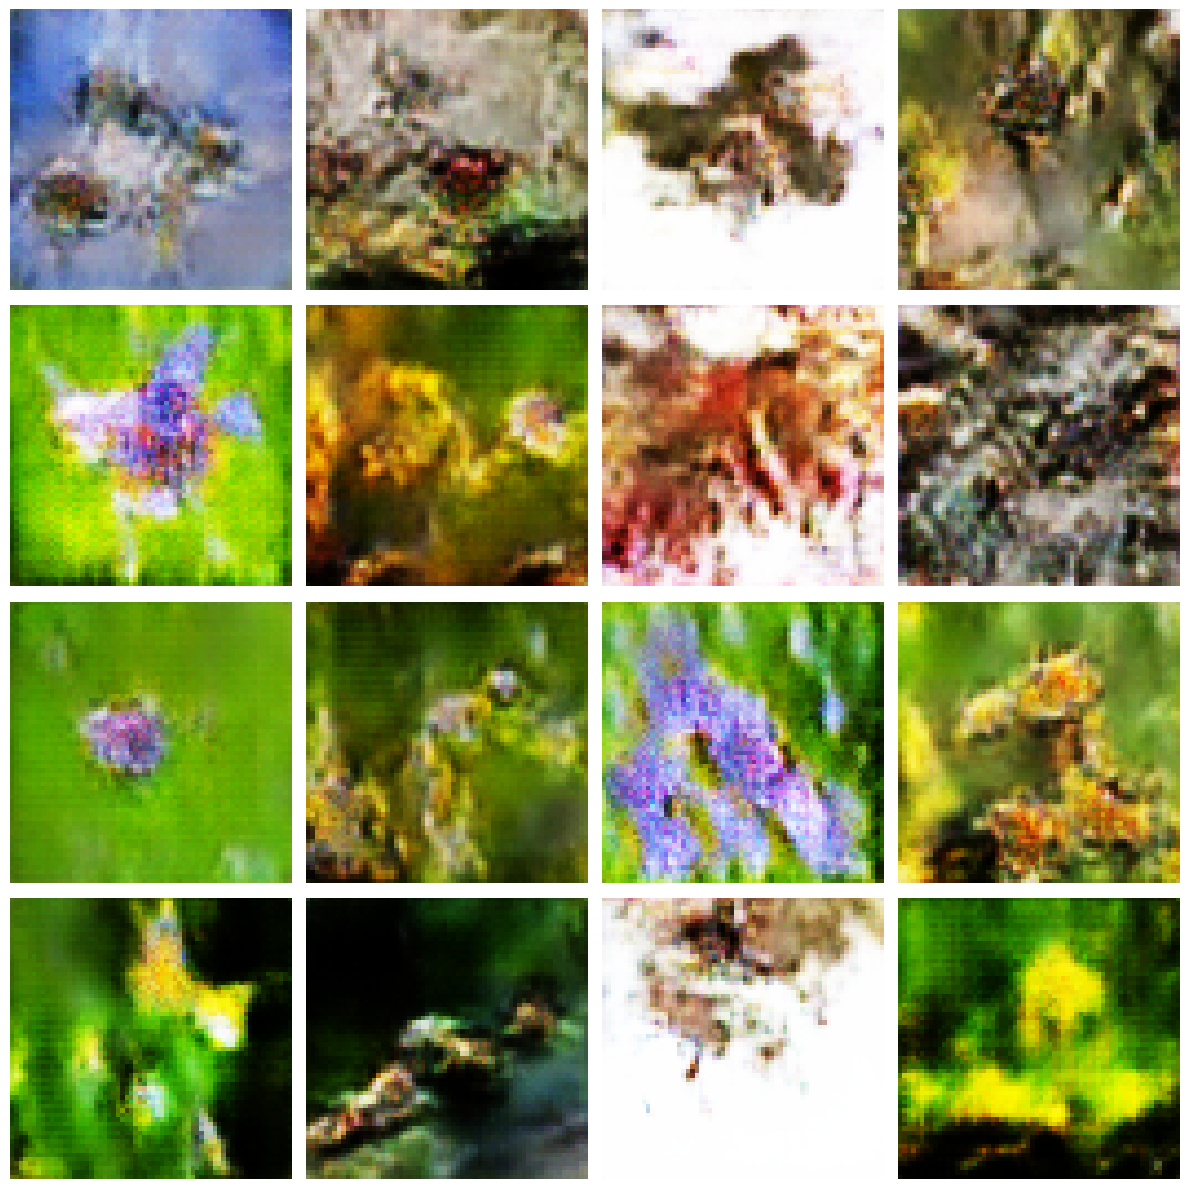

--------------------------------------------------


Epoch 46/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 46/100:  23%|██▎       | 30/128 [00:05<00:13,  7.01it/s, D_loss=-2461.1855, G_loss=18228.7734, GP=111.0920] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 46/100:  27%|██▋       | 34/128 [00:06<00:13,  7.09it/s, D_loss=-8272.7715, G_loss=21846.2715, GP=124.8414]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 46/100:  59%|█████▊    | 75/128 [00:13<00:09,  5.74it/s, D_loss=-633.6652, G_loss=14881.8340, GP=19.8372]   /home/2024032/oaqebl0


Epoch [46/100]
  Discriminator Loss: -5167.6407
  Generator Loss: 16028.5913
--------------------------------------------------


Epoch 47/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 47/100:  19%|█▉        | 24/128 [00:04<00:14,  7.27it/s, D_loss=-25763.1738, G_loss=17279.0664, GP=337.5046]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
Epoch 47/100:  27%|██▋       | 35/128 [00:07<00:15,  6.13it/s, D_loss=-4209.3979, G_loss=20259.4082, GP=172.3676] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in byt


Epoch [47/100]
  Discriminator Loss: -10131.6059
  Generator Loss: 19469.1233
--------------------------------------------------


...


Epoch [48/100]
  Discriminator Loss: -1867.5027
  Generator Loss: 18994.8643
--------------------------------------------------


Epoch 49/100:   5%|▌         | 7/128 [00:01<00:26,  4.65it/s, D_loss=-1712.0978, G_loss=20386.0859, GP=189.3342]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 49/100:  23%|██▎       | 29/128 [00:05<00:13,  7.57it/s, D_loss=-3005.3889, G_loss=21341.4434, GP=29.5693]  /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 49/100:  27%|██▋       | 34/128 [00:07<00:16,  5.68it/s, D_loss=-10999.9365, G_loss=15905.2344, GP=56.6910] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 49/100:  61%|██████    | 78/128 [00:14<00:07,  6.67it/s, D_loss=-4601


Epoch [49/100]
  Discriminator Loss: -10528.2647
  Generator Loss: 24956.7968
--------------------------------------------------


Epoch 50/100:   3%|▎         | 4/128 [00:01<00:29,  4.18it/s, D_loss=-30581.2617, G_loss=22390.3945, GP=727.1722]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 50/100:  25%|██▌       | 32/128 [00:06<00:16,  5.94it/s, D_loss=-15834.0234, G_loss=5858.0576, GP=454.6616] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
Epoch 50/100:  45%|████▍     | 57/128 [00:11<00:10,  6.67it/s, D_loss=-819.6036, G_loss=15677.1084, GP=19.0757]   /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 50/100:  46%|████▌     | 59/128 [00:11<00:12,  5.70it/s, D_loss=-924.0187,


Epoch [50/100]
  Discriminator Loss: -4654.2604
  Generator Loss: 17987.7499
  Generating samples...


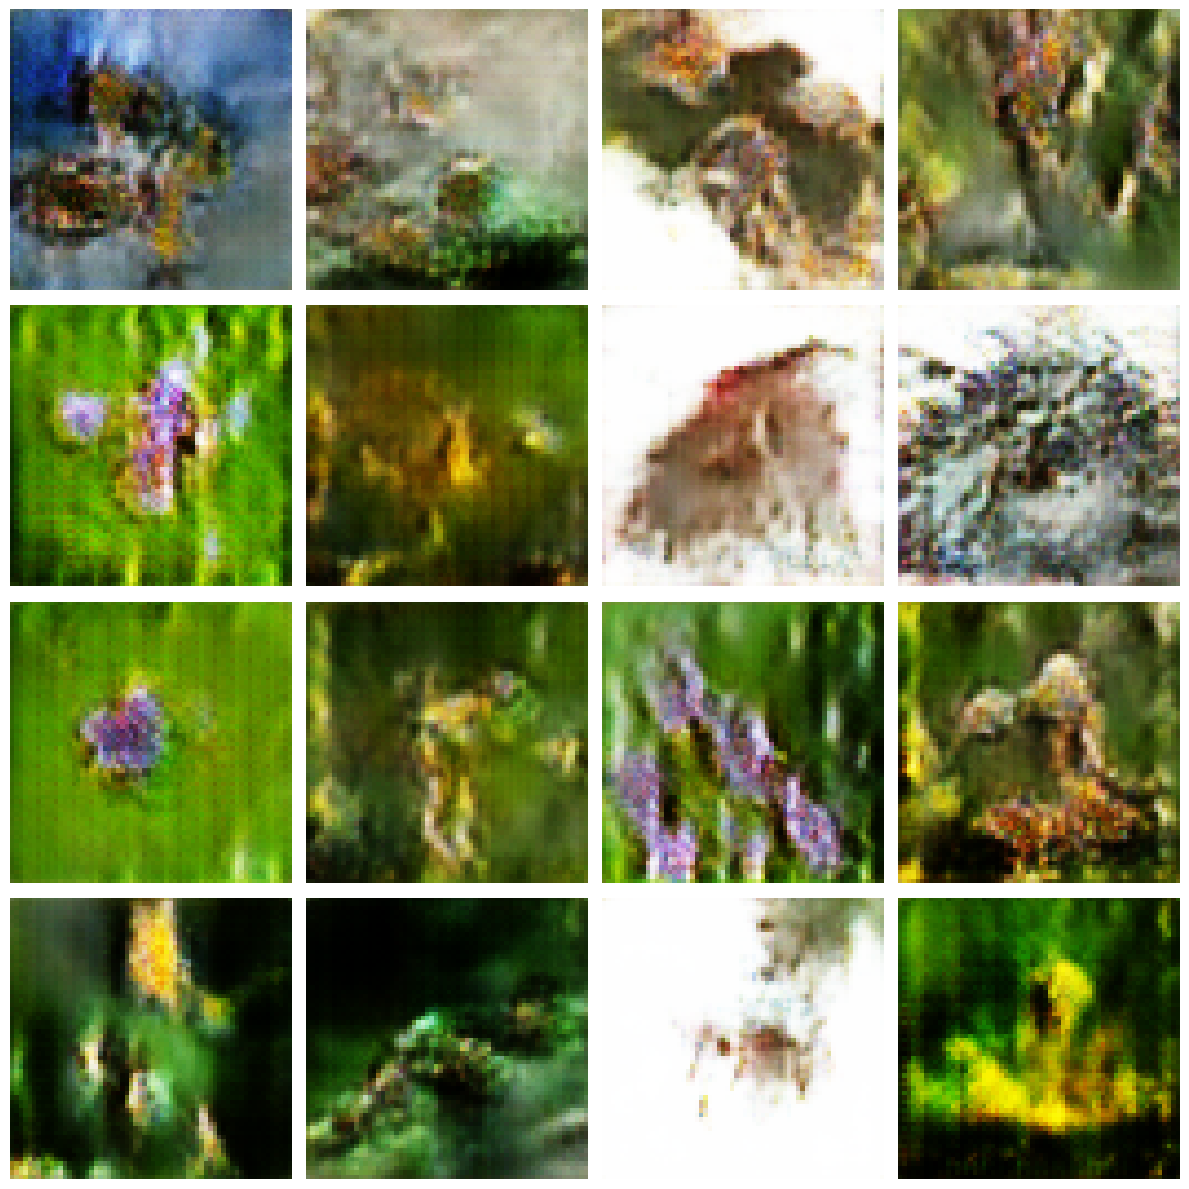

Checkpoint saved at epoch 50
--------------------------------------------------


Epoch 51/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
Epoch 51/100:   5%|▌         | 7/128 [00:01<00:21,  5.50it/s, D_loss=-11495.7002, G_loss=19840.4570, GP=178.7738]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 51/100:  10%|█         | 13/128 [00:02<00:15,  7.23it/s, D_loss=-10124.9023, G_loss=28620.3848, GP=277.6823]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in byte


Epoch [51/100]
  Discriminator Loss: -1626.3143
  Generator Loss: 15726.2586
--------------------------------------------------


Epoch 52/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 52/100:  16%|█▌        | 20/128 [00:04<00:25,  4.21it/s, D_loss=-1797.2792, G_loss=15577.4121, GP=131.3626]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
Epoch 52/100:  16%|█▋        | 21/128 [00:04<00:23,  4.63it/s, D_loss=-2671.4795, G_loss=16180.5674, GP=126.6495]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 52/100:  18%|█▊        | 23/128 [00:04<00:17,  6.17it/s, D_loss=-2758.2183, G_loss=16360.0488, GP=73.5715] /home/2024032/oaqebl01/.local


Epoch [52/100]
  Discriminator Loss: -1704.6516
  Generator Loss: 15810.7201
--------------------------------------------------


...


Epoch [53/100]
  Discriminator Loss: -3788.0088
  Generator Loss: 18315.4527
--------------------------------------------------


Epoch 54/100:   4%|▍         | 5/128 [00:01<00:28,  4.36it/s, D_loss=-4388.5918, G_loss=19932.0840, GP=115.9523]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 54/100:  22%|██▏       | 28/128 [00:05<00:16,  6.12it/s, D_loss=-5764.5469, G_loss=23714.5586, GP=100.8177] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 54/100:  28%|██▊       | 36/128 [00:06<00:12,  7.21it/s, D_loss=-13194.2041, G_loss=27256.7891, GP=85.9140] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 54/100:  34%|███▎      | 43/128 [00:08<00:17,  4.91it/s, D_loss=-2219


Epoch [54/100]
  Discriminator Loss: -13062.0206
  Generator Loss: 22713.5298
--------------------------------------------------


Epoch 55/100:   2%|▏         | 3/128 [00:00<00:31,  3.98it/s, D_loss=-2372.6326, G_loss=31835.8672, GP=55.4463]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 55/100:  12%|█▎        | 16/128 [00:03<00:19,  5.78it/s, D_loss=-823.3295, G_loss=22993.5527, GP=16.9899] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 55/100:  37%|███▋      | 47/128 [00:09<00:13,  6.11it/s, D_loss=-766.9014, G_loss=19667.2676, GP=50.9270] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 55/100:  53%|█████▎    | 68/128 [00:12<00:09,  6.61it/s, D_loss=-833.0392,


Epoch [55/100]
  Discriminator Loss: -899.8203
  Generator Loss: 22405.6434
  Generating samples...


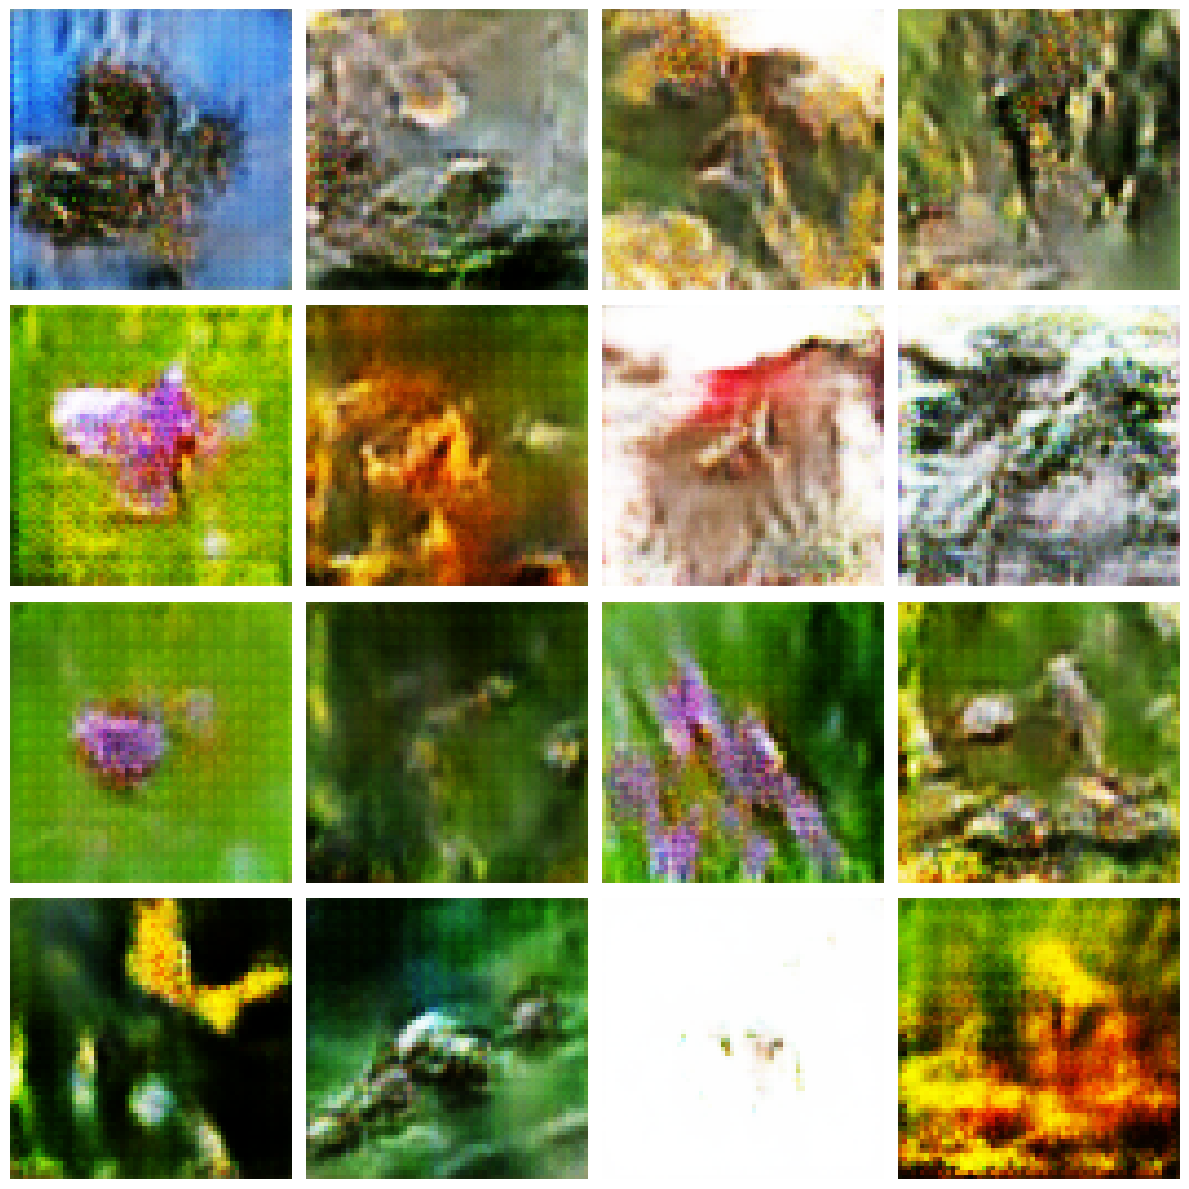

--------------------------------------------------


Epoch 56/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 56/100:   1%|          | 1/128 [00:00<01:25,  1.48it/s, D_loss=-1100.9607, G_loss=23701.8438, GP=34.9559]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 56/100:  23%|██▎       | 30/128 [00:06<00:16,  6.10it/s, D_loss=-1424.7896, G_loss=23643.9902, GP=33.1855]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4


Epoch [56/100]
  Discriminator Loss: -1260.0251
  Generator Loss: 22495.5592
--------------------------------------------------


Epoch 57/100:   5%|▍         | 6/128 [00:01<00:24,  4.98it/s, D_loss=-2983.9136, G_loss=21916.8496, GP=68.4889] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 57/100:   9%|▊         | 11/128 [00:02<00:20,  5.67it/s, D_loss=-4030.6572, G_loss=23670.0820, GP=98.6130]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 57/100:  10%|█         | 13/128 [00:03<00:17,  6.39it/s, D_loss=-4838.2041, G_loss=21386.5820, GP=129.2716]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 57/100:  29%|██▉       | 37/128 [00:06<00:11,  7.70it/s, D_loss=-2219.62


Epoch [57/100]
  Discriminator Loss: -2399.3324
  Generator Loss: 24218.4198
--------------------------------------------------


...


Epoch [58/100]
  Discriminator Loss: -2317.1152
  Generator Loss: 24104.2221
--------------------------------------------------


Epoch 59/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 59/100:  10%|█         | 13/128 [00:02<00:19,  6.05it/s, D_loss=-1125.2676, G_loss=23854.0859, GP=86.0250]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
Epoch 59/100:  15%|█▍        | 19/128 [00:03<00:18,  5.83it/s, D_loss=-1986.1779, G_loss=22765.0000, GP=67.3851]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 59/100:  43%|████▎     | 55/128 [00:10<00:16,  4.41it/s, D_loss=-667.4525, G_loss=19816.2891, GP=119.7385] /home/2024032/oaqebl01/.local/l


Epoch [59/100]
  Discriminator Loss: -3287.1886
  Generator Loss: 24092.7215
--------------------------------------------------


Epoch 60/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 60/100:   3%|▎         | 4/128 [00:01<00:26,  4.60it/s, D_loss=-1224.8926, G_loss=26051.7852, GP=26.0789]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 60/100:  24%|██▍       | 31/128 [00:06<00:16,  5.92it/s, D_loss=-6526.4971, G_loss=36594.1953, GP=140.1155] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 60/100:  78%|███████▊  | 100/128 [00:18<00:04,  6.89it/s, D_loss=-668.8928, G_loss=21387.5000, GP=20.1385]  /home/2024032/oaqebl01/


Epoch [60/100]
  Discriminator Loss: -1279.1513
  Generator Loss: 24311.4657
  Generating samples...


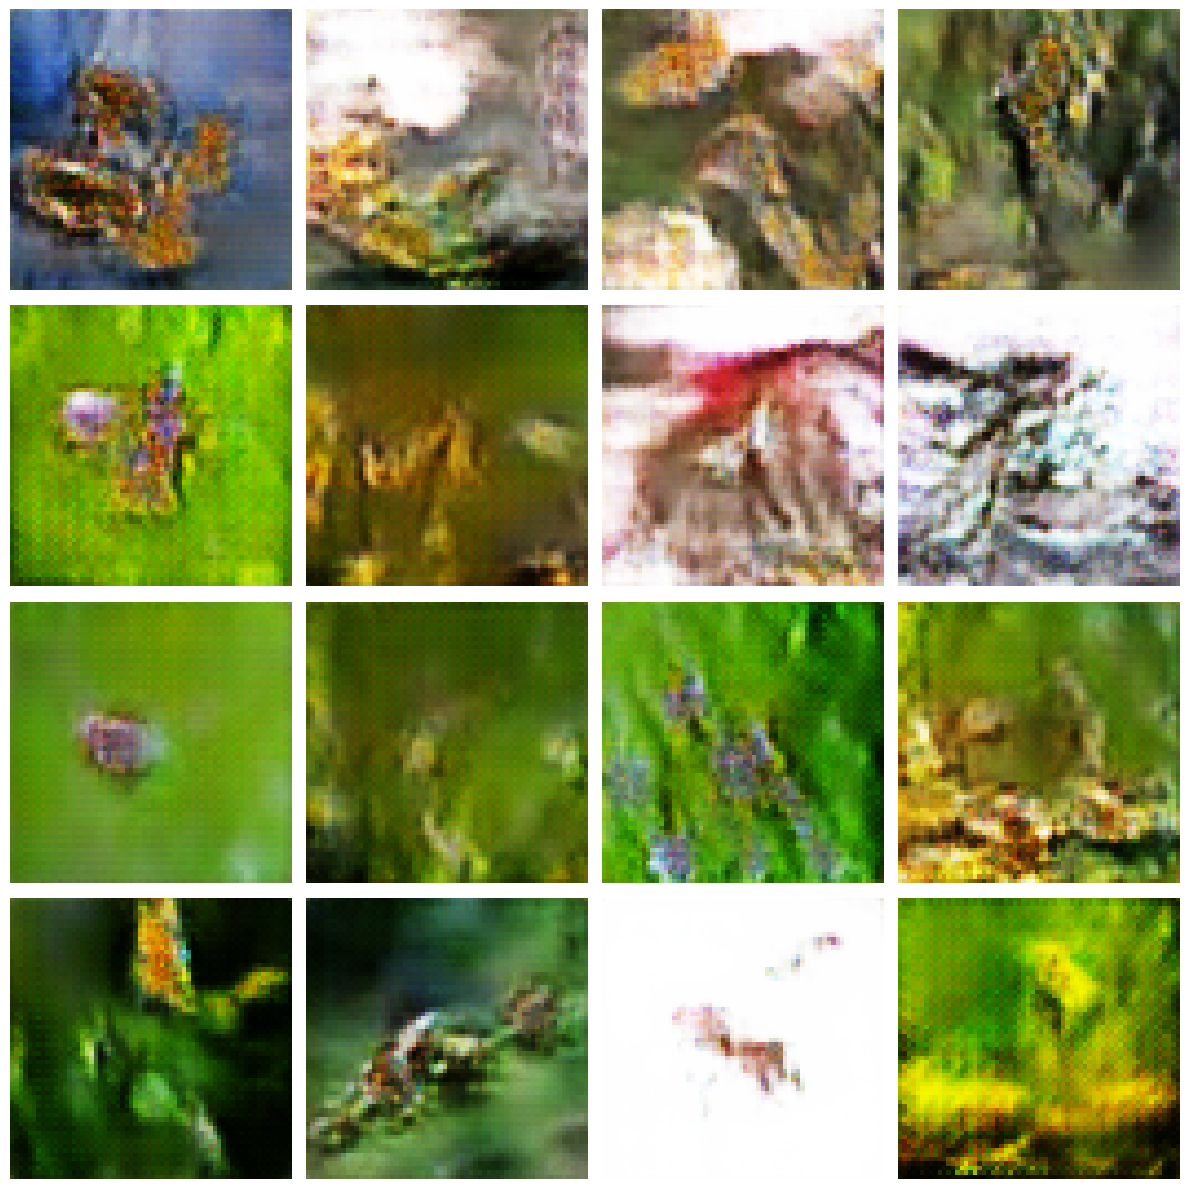

Checkpoint saved at epoch 60
--------------------------------------------------


Epoch 61/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 61/100:   2%|▏         | 2/128 [00:00<00:51,  2.43it/s, D_loss=-3.6139, G_loss=20541.0508, GP=32.9413]  /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 61/100:   9%|▉         | 12/128 [00:03<00:19,  6.08it/s, D_loss=-1243.3909, G_loss=23045.2383, GP=53.2787]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in byt


Epoch [61/100]
  Discriminator Loss: -1789.7189
  Generator Loss: 23049.1862
--------------------------------------------------


Epoch 62/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 62/100:  25%|██▌       | 32/128 [00:06<00:17,  5.64it/s, D_loss=-3196.4197, G_loss=28578.0430, GP=39.4928]  /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 62/100:  36%|███▌      | 46/128 [00:08<00:13,  6.25it/s, D_loss=-2078.8748, G_loss=25234.9180, GP=69.5266]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to rea


Epoch [62/100]
  Discriminator Loss: -2990.9591
  Generator Loss: 25391.5403
--------------------------------------------------


...


Epoch [63/100]
  Discriminator Loss: -5234.9518
  Generator Loss: 25007.4145
--------------------------------------------------


Epoch 64/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 64/100:   6%|▋         | 8/128 [00:01<00:21,  5.66it/s, D_loss=-155.1751, G_loss=23948.6348, GP=20.7100]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 64/100:  23%|██▎       | 29/128 [00:05<00:19,  5.15it/s, D_loss=12.8391, G_loss=24268.1875, GP=15.7232]  /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 64/100:  24%|██▍       | 31/128 [00:06<00:14,  6.63it/s, D_loss=-341.3457, G_loss=23972.4102, GP=17.8004]/home/2024032/oaqebl01/.local/


Epoch [64/100]
  Discriminator Loss: -266.0594
  Generator Loss: 23389.0739
--------------------------------------------------


Epoch 65/100:  20%|██        | 26/128 [00:05<00:20,  4.93it/s, D_loss=-672.2927, G_loss=22750.8008, GP=32.0467] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 65/100:  27%|██▋       | 35/128 [00:07<00:15,  6.15it/s, D_loss=-750.3882, G_loss=22716.1289, GP=43.0381] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 65/100:  35%|███▌      | 45/128 [00:08<00:14,  5.76it/s, D_loss=-585.8452, G_loss=21910.1621, GP=30.3485] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 65/100:  37%|███▋      | 47/128 [00:08<00:12,  6.59it/s, D_loss=-490.1932


Epoch [65/100]
  Discriminator Loss: -986.3514
  Generator Loss: 22896.5708
  Generating samples...


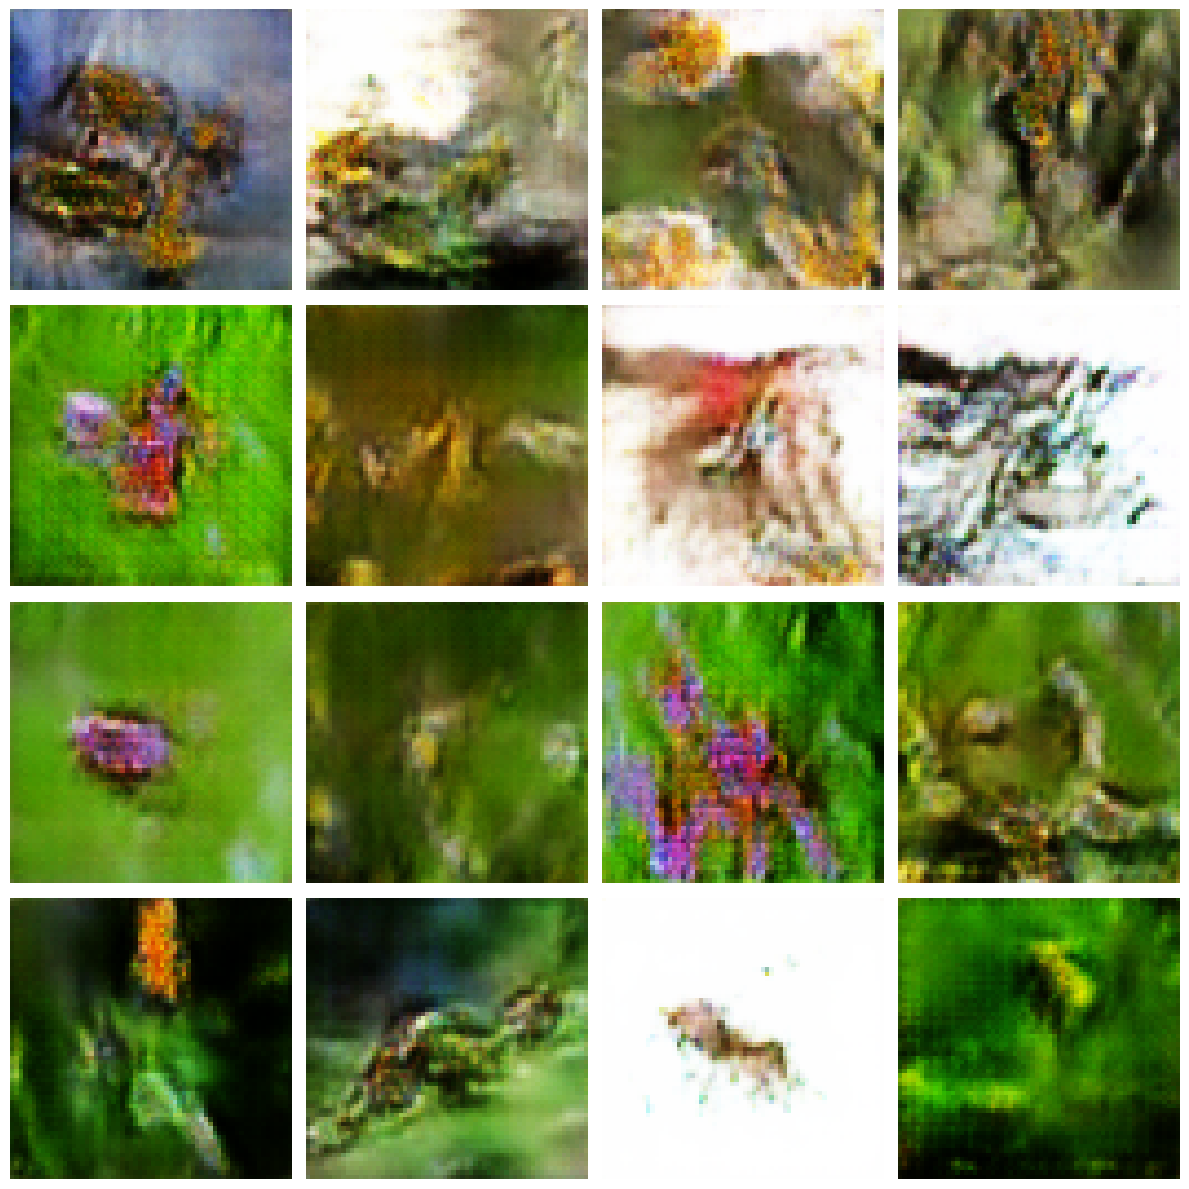

--------------------------------------------------


Epoch 66/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 66/100:   9%|▉         | 12/128 [00:02<00:18,  6.44it/s, D_loss=-2926.0869, G_loss=20570.6211, GP=149.5267]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 66/100:  19%|█▉        | 24/128 [00:04<00:16,  6.35it/s, D_loss=-3427.9785, G_loss=22219.4805, GP=161.7620]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 66/100:  61%|██████    | 78/128 [00:14<00:10,  4.90it/s, D_loss=-1665.5675, G_loss=29970.8320, GP=50.4610]  /home/2024032/oaqebl01


Epoch [66/100]
  Discriminator Loss: -3107.5632
  Generator Loss: 26458.3362
--------------------------------------------------


Epoch 67/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 67/100:   2%|▏         | 2/128 [00:01<00:58,  2.14it/s, D_loss=-22.3546, G_loss=24263.1113, GP=20.9622]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 67/100:  10%|█         | 13/128 [00:03<00:34,  3.31it/s, D_loss=-786.6403, G_loss=25613.4082, GP=43.1205]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 67/100:  80%|████████  | 103/128 [00:19<00:04,  5.42it/s, D_loss=-4492.5410, G_loss=28933.3965, GP=75.3024] /home/2024032/oaqebl01/.loca


Epoch [67/100]
  Discriminator Loss: -912.1858
  Generator Loss: 25048.6643
--------------------------------------------------


...


Epoch [68/100]
  Discriminator Loss: -2878.3569
  Generator Loss: 27298.9945
--------------------------------------------------


Epoch 69/100:   2%|▏         | 3/128 [00:01<00:42,  2.95it/s, D_loss=-208.7934, G_loss=26619.2031, GP=20.0558]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 69/100:   9%|▊         | 11/128 [00:02<00:24,  4.72it/s, D_loss=-388.5576, G_loss=28297.1055, GP=21.5022]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 69/100:  11%|█         | 14/128 [00:03<00:20,  5.44it/s, D_loss=-1094.6305, G_loss=29350.1719, GP=25.8744]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 69/100:  41%|████▏     | 53/128 [00:10<00:12,  5.96it/s, D_loss=-3159.4019, 


Epoch [69/100]
  Discriminator Loss: -2649.9467
  Generator Loss: 27255.9904
--------------------------------------------------


Epoch 70/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
Epoch 70/100:  13%|█▎        | 17/128 [00:03<00:17,  6.34it/s, D_loss=-1929.7246, G_loss=32850.0781, GP=81.5928]   /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 70/100:  17%|█▋        | 22/128 [00:04<00:16,  6.54it/s, D_loss=-419.9590, G_loss=30425.1406, GP=37.3420]  /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 70/100:  23%|██▎       | 29/128 [00:05<00:18,  5.45it/s, D_loss=183.2650, G_loss=29173.8730, GP=16.0945]  /home/2024032/oaqebl01/.loca


Epoch [70/100]
  Discriminator Loss: -220.8473
  Generator Loss: 28392.5077
  Generating samples...


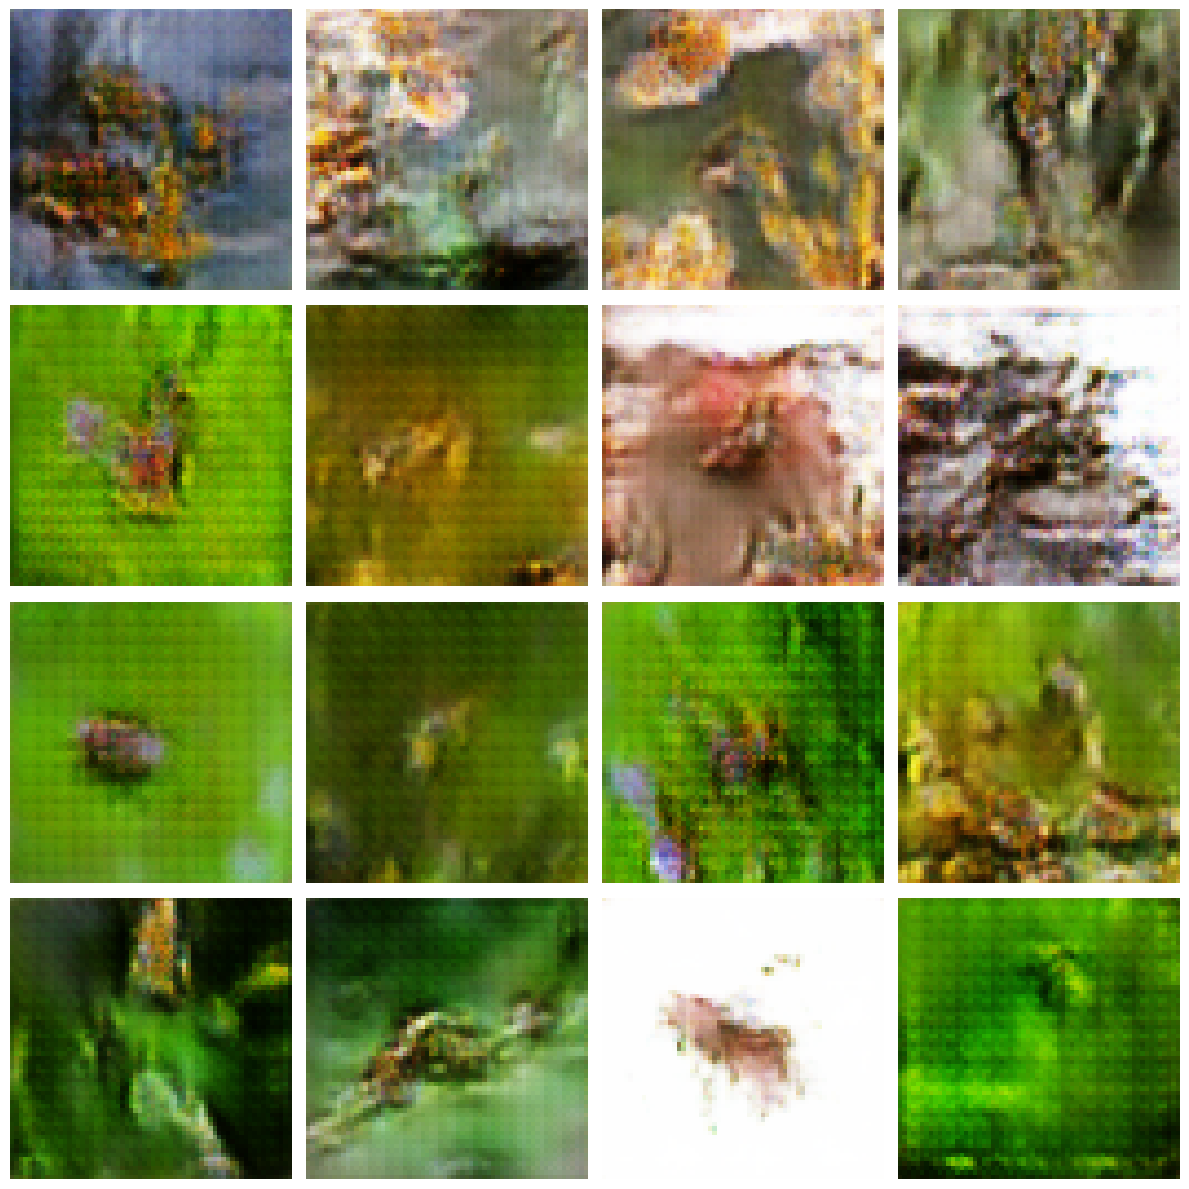

Checkpoint saved at epoch 70
--------------------------------------------------


Epoch 71/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 71/100:  16%|█▋        | 21/128 [00:04<00:15,  6.87it/s, D_loss=-392.8687, G_loss=27111.2285, GP=7.9717] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 71/100:  21%|██        | 27/128 [00:05<00:15,  6.64it/s, D_loss=-295.2215, G_loss=26875.5078, GP=9.3853] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 71/100:  31%|███▏      | 40/128 [00:07<00:18,  4.75it/s, D_loss=-421.2657, G_loss=27868.0254, GP=11.0072]/home/2024032/oaqebl01/.local


Epoch [71/100]
  Discriminator Loss: -229.3101
  Generator Loss: 27353.2624
--------------------------------------------------


Epoch 72/100:  10%|█         | 13/128 [00:02<00:16,  6.95it/s, D_loss=-228.7302, G_loss=26908.7266, GP=9.3344] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 72/100:  20%|█▉        | 25/128 [00:04<00:13,  7.58it/s, D_loss=-406.5312, G_loss=27563.5156, GP=13.0543]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 72/100:  22%|██▏       | 28/128 [00:05<00:14,  7.13it/s, D_loss=-760.3082, G_loss=28508.6719, GP=16.7362]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 72/100:  30%|██▉       | 38/128 [00:08<00:31,  2.86it/s, D_loss=-637.0181, G


Epoch [72/100]
  Discriminator Loss: -308.6215
  Generator Loss: 27269.0268
--------------------------------------------------


...


Epoch [73/100]
  Discriminator Loss: -476.4283
  Generator Loss: 27365.8842
--------------------------------------------------


Epoch 74/100:  16%|█▌        | 20/128 [00:04<00:16,  6.43it/s, D_loss=-1266.8323, G_loss=30779.1602, GP=56.3248] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 74/100:  18%|█▊        | 23/128 [00:05<00:26,  3.89it/s, D_loss=-1791.2097, G_loss=25856.5508, GP=25.9066]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 74/100:  41%|████▏     | 53/128 [00:10<00:11,  6.56it/s, D_loss=-509.7621, G_loss=26393.2285, GP=30.7062] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 74/100:  70%|███████   | 90/128 [00:16<00:06,  6.07it/s, D_loss=-1007.81


Epoch [74/100]
  Discriminator Loss: -895.4821
  Generator Loss: 27031.5949
--------------------------------------------------


Epoch 75/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 75/100:   5%|▌         | 7/128 [00:01<00:23,  5.20it/s, D_loss=-2517.0647, G_loss=30497.6484, GP=121.3974]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 75/100:  34%|███▍      | 44/128 [00:08<00:13,  6.33it/s, D_loss=-2507.1375, G_loss=29577.7773, GP=72.9745] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 75/100:  38%|███▊      | 48/128 [00:09<00:16,  4.86it/s, D_loss=-4554.0146, G_loss=25063.0430, GP=143.5067]/home/2024032/oaqebl01/.


Epoch [75/100]
  Discriminator Loss: -1900.0198
  Generator Loss: 27828.0550
  Generating samples...


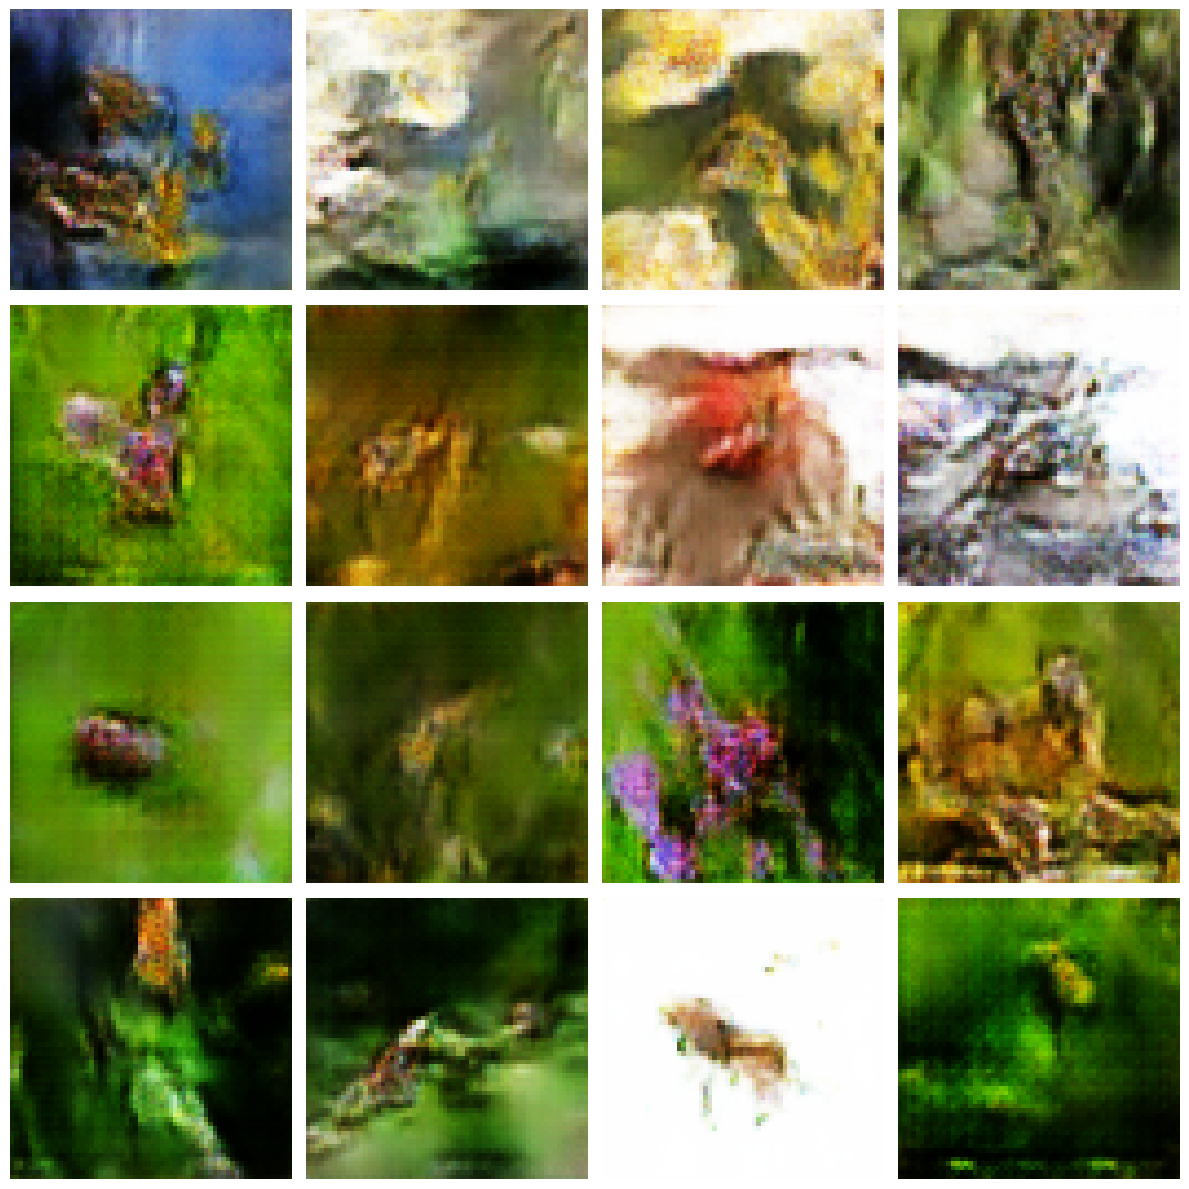

--------------------------------------------------


Epoch 76/100:   7%|▋         | 9/128 [00:01<00:19,  6.25it/s, D_loss=-3379.1724, G_loss=26383.7812, GP=101.2519]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 76/100:  10%|█         | 13/128 [00:02<00:21,  5.32it/s, D_loss=693.7850, G_loss=27050.3965, GP=69.4586]    /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 76/100:  13%|█▎        | 17/128 [00:03<00:16,  6.77it/s, D_loss=-5057.1807, G_loss=37945.1094, GP=94.8511]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 76/100:  23%|██▎       | 29/128 [00:06<00:19,  5.01it/s, D_loss=-12828.


Epoch [76/100]
  Discriminator Loss: -2154.3471
  Generator Loss: 28343.5960
--------------------------------------------------


Epoch 77/100:   4%|▍         | 5/128 [00:01<00:30,  4.08it/s, D_loss=-4991.3779, G_loss=24632.6680, GP=113.1114]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 77/100:  12%|█▏        | 15/128 [00:03<00:20,  5.52it/s, D_loss=-2575.4385, G_loss=24694.6094, GP=67.1647] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 77/100:  20%|██        | 26/128 [00:04<00:14,  6.94it/s, D_loss=-1214.8407, G_loss=31032.6953, GP=29.4478]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 77/100:  73%|███████▎  | 94/128 [00:17<00:05,  6.04it/s, D_loss=-17444.1


Epoch [77/100]
  Discriminator Loss: -5294.7882
  Generator Loss: 29398.0709
--------------------------------------------------


...


Epoch [78/100]
  Discriminator Loss: -4824.5918
  Generator Loss: 29785.5115
--------------------------------------------------


Epoch 79/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 79/100:   4%|▍         | 5/128 [00:01<00:29,  4.20it/s, D_loss=-938.8315, G_loss=29216.8926, GP=21.1723]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 79/100:  15%|█▍        | 19/128 [00:03<00:19,  5.71it/s, D_loss=-324.2620, G_loss=29596.2129, GP=27.4463]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
Epoch 79/100:  26%|██▌       | 33/128 [00:06<00:13,  6.84it/s, D_loss=-1369.2821, G_loss=26258.0000, GP=21.5816]/home/2024032/oaqebl01/.local/lib/p


Epoch [79/100]
  Discriminator Loss: -709.9443
  Generator Loss: 28350.8547
--------------------------------------------------


Epoch 80/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 80/100:   1%|          | 1/128 [00:00<01:44,  1.21it/s, D_loss=-1238.0786, G_loss=30164.4551, GP=61.2859]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 80/100:  18%|█▊        | 23/128 [00:04<00:16,  6.30it/s, D_loss=-4067.5105, G_loss=22779.6484, GP=77.6509] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 80/100:  34%|███▍      | 44/128 [00:08<00:16,  5.17it/s, D_loss=-413.6334, G_loss=27378.5703, GP=13.5183]   /home/2024032/oaqebl01/.


Epoch [80/100]
  Discriminator Loss: -1720.2738
  Generator Loss: 28315.6102
  Generating samples...


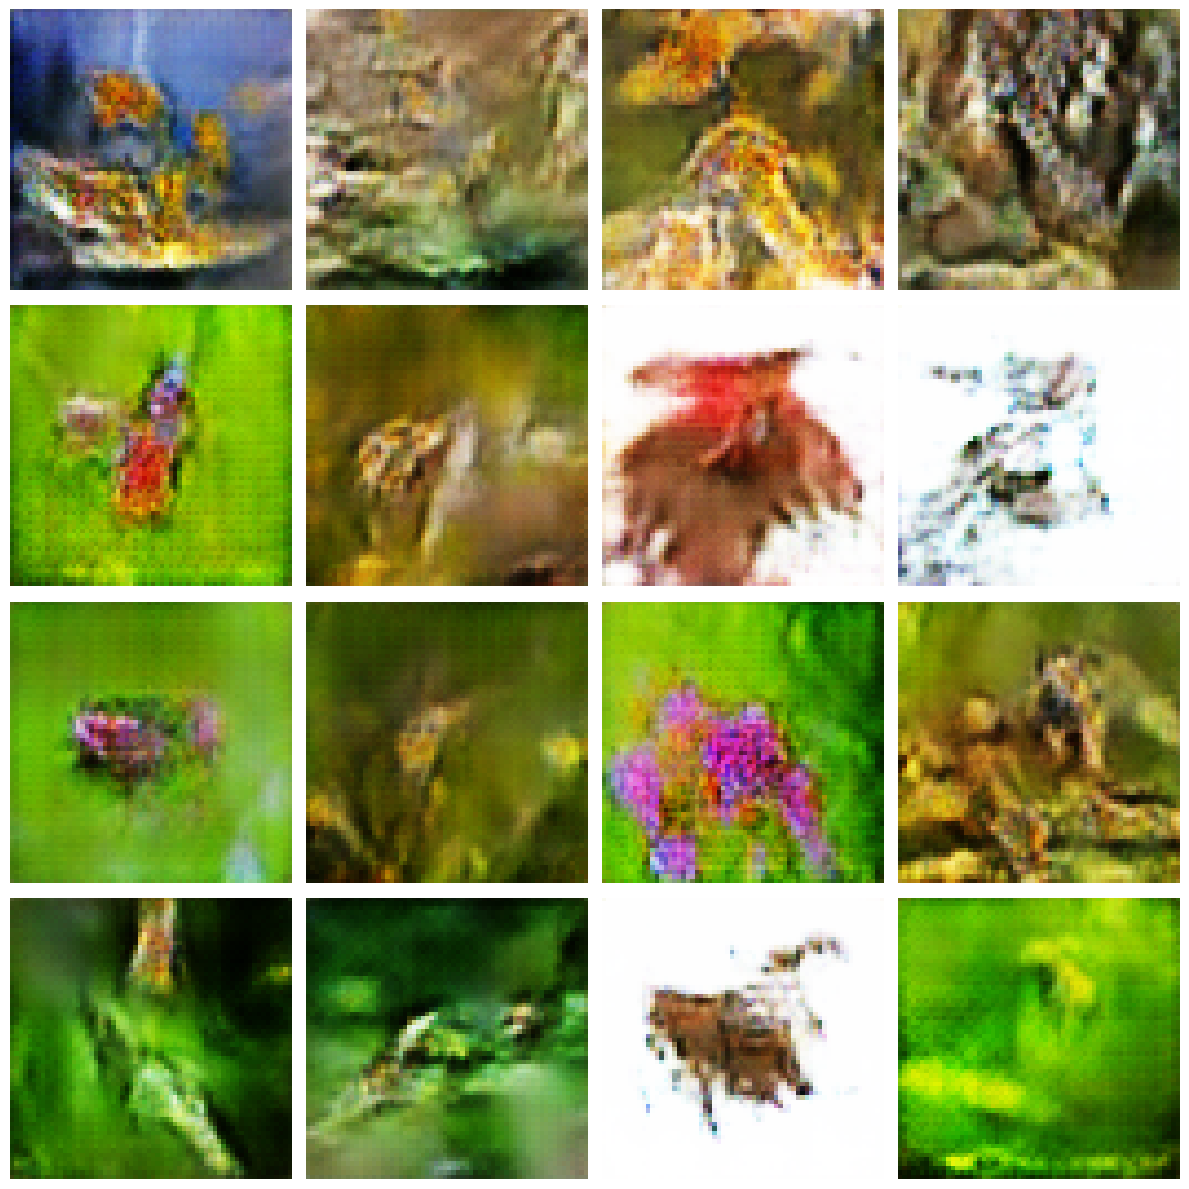

Checkpoint saved at epoch 80
--------------------------------------------------


Epoch 81/100:   5%|▌         | 7/128 [00:01<00:19,  6.08it/s, D_loss=-2071.9431, G_loss=27000.1582, GP=51.0760]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 81/100:  16%|█▋        | 21/128 [00:04<00:19,  5.44it/s, D_loss=-20593.1250, G_loss=46064.7109, GP=112.7260]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 81/100:  23%|██▎       | 30/128 [00:05<00:16,  5.81it/s, D_loss=-9232.2754, G_loss=32436.4141, GP=189.1541] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 81/100:  50%|█████     | 64/128 [00:11<00:11,  5.67it/s, D_loss=-307.5


Epoch [81/100]
  Discriminator Loss: -1699.4325
  Generator Loss: 27854.4168
--------------------------------------------------


Epoch 82/100:   5%|▌         | 7/128 [00:01<00:21,  5.68it/s, D_loss=31.1884, G_loss=26576.9785, GP=17.9850]  /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 82/100:  12%|█▎        | 16/128 [00:03<00:17,  6.24it/s, D_loss=-406.5974, G_loss=26835.4922, GP=11.2582]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 82/100:  13%|█▎        | 17/128 [00:03<00:16,  6.87it/s, D_loss=-108.5337, G_loss=26794.6836, GP=10.7121]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 82/100:  52%|█████▏    | 67/128 [00:12<00:09,  6.68it/s, D_loss=-537.5400, G_


Epoch [82/100]
  Discriminator Loss: -272.1384
  Generator Loss: 26204.4825
--------------------------------------------------


...


Epoch [83/100]
  Discriminator Loss: -497.6805
  Generator Loss: 26368.7736
--------------------------------------------------


Epoch 84/100:   1%|          | 1/128 [00:00<01:40,  1.27it/s, D_loss=-1600.0103, G_loss=26407.6348, GP=37.5490]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 84/100:   9%|▉         | 12/128 [00:03<00:35,  3.25it/s, D_loss=-844.9971, G_loss=27169.5117, GP=31.1774]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 84/100:  15%|█▍        | 19/128 [00:04<00:18,  5.88it/s, D_loss=-1497.2504, G_loss=25595.3828, GP=64.1414]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 84/100:  20%|██        | 26/128 [00:05<00:15,  6.74it/s, D_loss=-1067.2510,


Epoch [84/100]
  Discriminator Loss: -998.3251
  Generator Loss: 27112.0386
--------------------------------------------------


Epoch 85/100:   2%|▏         | 2/128 [00:00<00:47,  2.66it/s, D_loss=-1275.0842, G_loss=26865.1367, GP=50.3070]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 85/100:  19%|█▉        | 24/128 [00:04<00:16,  6.39it/s, D_loss=-3324.6018, G_loss=30038.8867, GP=188.6929]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 85/100:  24%|██▍       | 31/128 [00:06<00:25,  3.79it/s, D_loss=-399.2606, G_loss=26819.5273, GP=85.9880]  /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 85/100:  58%|█████▊    | 74/128 [00:13<00:09,  5.63it/s, D_loss=-4294.23


Epoch [85/100]
  Discriminator Loss: -2779.9161
  Generator Loss: 28300.0676
  Generating samples...


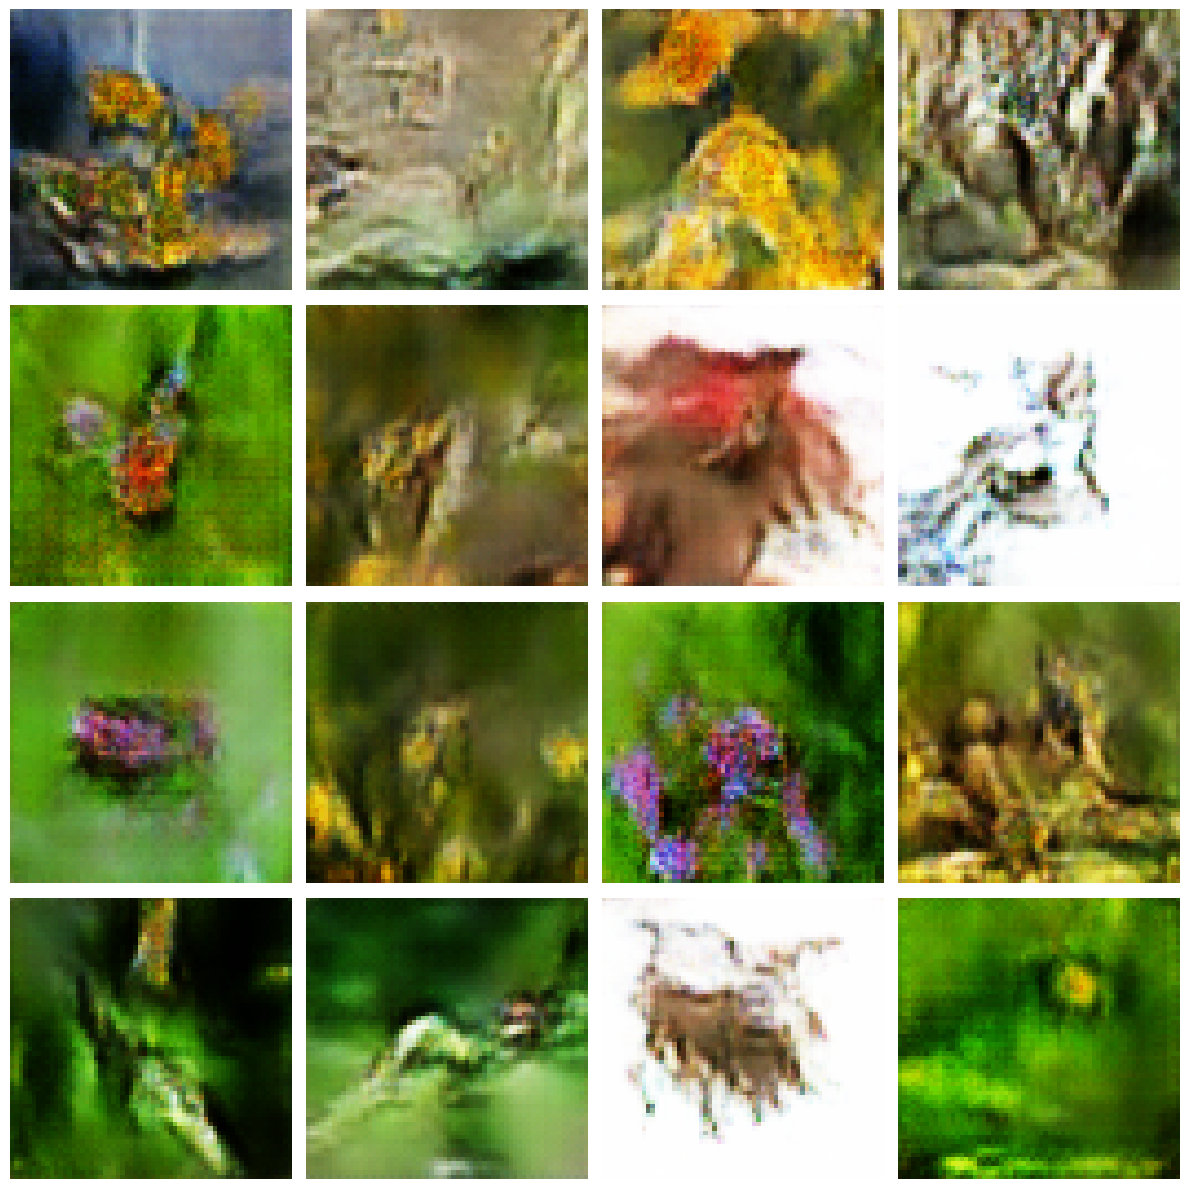

--------------------------------------------------


Epoch 86/100:  24%|██▍       | 31/128 [00:05<00:15,  6.42it/s, D_loss=-2259.7798, G_loss=25997.0645, GP=42.7464] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 86/100:  47%|████▋     | 60/128 [00:11<00:15,  4.33it/s, D_loss=-7974.4775, G_loss=32381.4492, GP=173.5057]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 86/100:  59%|█████▊    | 75/128 [00:13<00:08,  6.31it/s, D_loss=-2227.8403, G_loss=29196.5195, GP=143.2927] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 86/100:  72%|███████▏  | 92/128 [00:16<00:05,  7.01it/s, D_loss=-1173


Epoch [86/100]
  Discriminator Loss: -3400.0263
  Generator Loss: 30823.1651
--------------------------------------------------


Epoch 87/100:  20%|██        | 26/128 [00:05<00:17,  5.97it/s, D_loss=-686.3003, G_loss=28978.6523, GP=23.5567] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
Epoch 87/100:  30%|██▉       | 38/128 [00:07<00:19,  4.61it/s, D_loss=-663.3084, G_loss=30853.8027, GP=19.6057] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 87/100:  31%|███▏      | 40/128 [00:08<00:17,  4.89it/s, D_loss=-262.1952, G_loss=30063.5508, GP=22.3188]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 87/100:  35%|███▌      | 45/128 [00:09<00:13,  6.13it/s, D_loss=-2008.9058, G_lo


Epoch [87/100]
  Discriminator Loss: -1943.4470
  Generator Loss: 29771.8145
--------------------------------------------------


...


Epoch [88/100]
  Discriminator Loss: -718.6073
  Generator Loss: 28316.7232
--------------------------------------------------


Epoch 89/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 89/100:  70%|██████▉   | 89/128 [00:16<00:05,  6.63it/s, D_loss=-191.6985, G_loss=27641.2188, GP=9.0786] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
Epoch 89/100:  80%|████████  | 103/128 [00:19<00:04,  5.99it/s


Epoch [89/100]
  Discriminator Loss: -275.9031
  Generator Loss: 27172.7591
--------------------------------------------------


Epoch 90/100:   4%|▍         | 5/128 [00:01<00:24,  5.06it/s, D_loss=-412.7721, G_loss=27328.3789, GP=15.5607]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 90/100:  12%|█▎        | 16/128 [00:03<00:16,  6.69it/s, D_loss=-647.5022, G_loss=27232.3281, GP=16.1304] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 90/100:  16%|█▌        | 20/128 [00:03<00:14,  7.28it/s, D_loss=-898.2173, G_loss=28153.8398, GP=13.6291]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:


Epoch [90/100]
  Discriminator Loss: -615.2012
  Generator Loss: 27807.6826
  Generating samples...


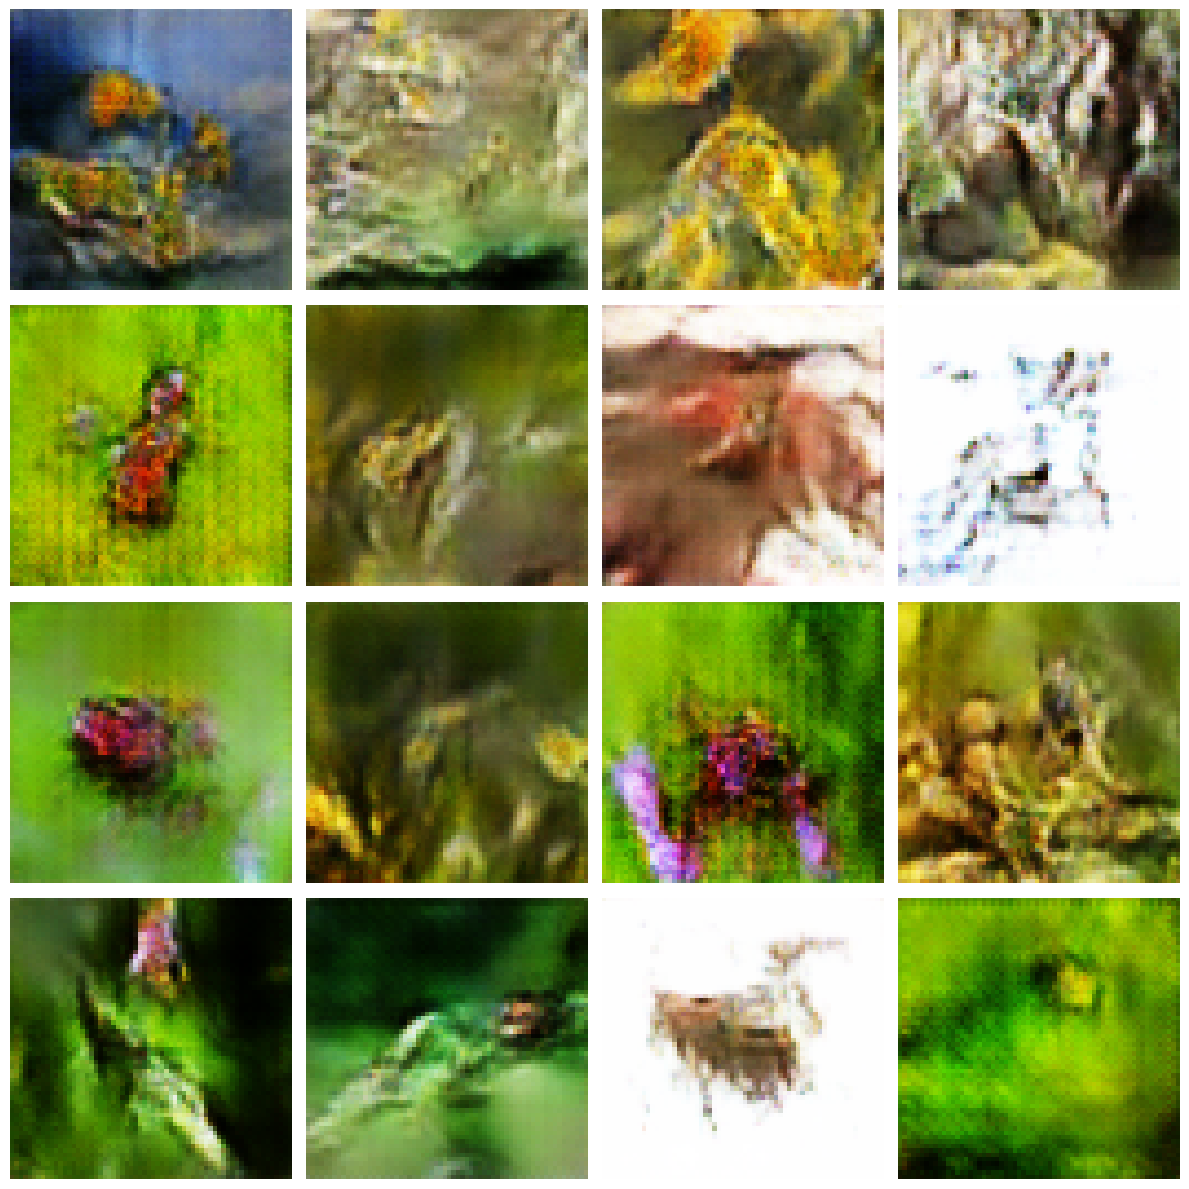

Checkpoint saved at epoch 90
--------------------------------------------------


Epoch 91/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 91/100:   7%|▋         | 9/128 [00:02<00:22,  5.33it/s, D_loss=-1442.3081, G_loss=27483.4766, GP=47.0051]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 91/100:  38%|███▊      | 48/128 [00:09<00:10,  7.51it/s, D_loss=-1674.6304, G_loss=27835.5078, GP=60.8536]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
Epoch 91/100:  47%|████▋     | 60/128 [00:11<00:11,  5.80it/s, D_loss=-1798.4839, G_loss=27574.2930, GP=79.4754]/home/2024032/oaqebl01/.local/lib


Epoch [91/100]
  Discriminator Loss: -1449.8650
  Generator Loss: 28539.0537
--------------------------------------------------


Epoch 92/100:   1%|          | 1/128 [00:00<01:34,  1.35it/s, D_loss=-2546.0608, G_loss=26451.5352, GP=130.1088]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 92/100:  12%|█▎        | 16/128 [00:03<00:14,  7.73it/s, D_loss=-5707.6797, G_loss=21073.1914, GP=200.3500]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
Epoch 92/100:  20%|█▉        | 25/128 [00:05<00:23,  4.46it/s, D_loss=-3729.8945, G_loss=32351.4727, GP=113.8701] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 92/100:  30%|██▉       | 38/128 [00:07<00:13,  6.69it/s, D_loss=-5843.7192, 


Epoch [92/100]
  Discriminator Loss: -2282.1026
  Generator Loss: 27095.1825
--------------------------------------------------


...


Epoch [93/100]
  Discriminator Loss: -2276.9601
  Generator Loss: 27079.0318
--------------------------------------------------


Epoch 94/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 94/100:   9%|▉         | 12/128 [00:02<00:17,  6.61it/s, D_loss=-135.5383, G_loss=25366.8281, GP=34.8159] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 94/100:  16%|█▌        | 20/128 [00:03<00:17,  6.24it/s, D_loss=-1293.0105, G_loss=27555.4883, GP=46.4345]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 94/100:  25%|██▌       | 32/128 [00:06<00:15,  6.24it/s, D_loss=423.3898, G_loss=25423.9434, GP=50.1612]  /home/2024032/oaqebl01/.lo


Epoch [94/100]
  Discriminator Loss: -1358.0927
  Generator Loss: 27529.8059
--------------------------------------------------


Epoch 95/100:  16%|█▌        | 20/128 [00:04<00:19,  5.46it/s, D_loss=-361.4474, G_loss=23809.2422, GP=50.9109] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 95/100:  38%|███▊      | 48/128 [00:08<00:11,  6.82it/s, D_loss=-562.9796, G_loss=27364.8809, GP=19.8265] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 95/100:  49%|████▉     | 63/128 [00:11<00:10,  6.42it/s, D_loss=216.5932, G_loss=24594.3730, GP=24.9810]  /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 95/100:  52%|█████▏    | 67/128 [00:12<00:09,  6.59it/s, D_loss=-767.0824


Epoch [95/100]
  Discriminator Loss: -576.1716
  Generator Loss: 25902.1424
  Generating samples...


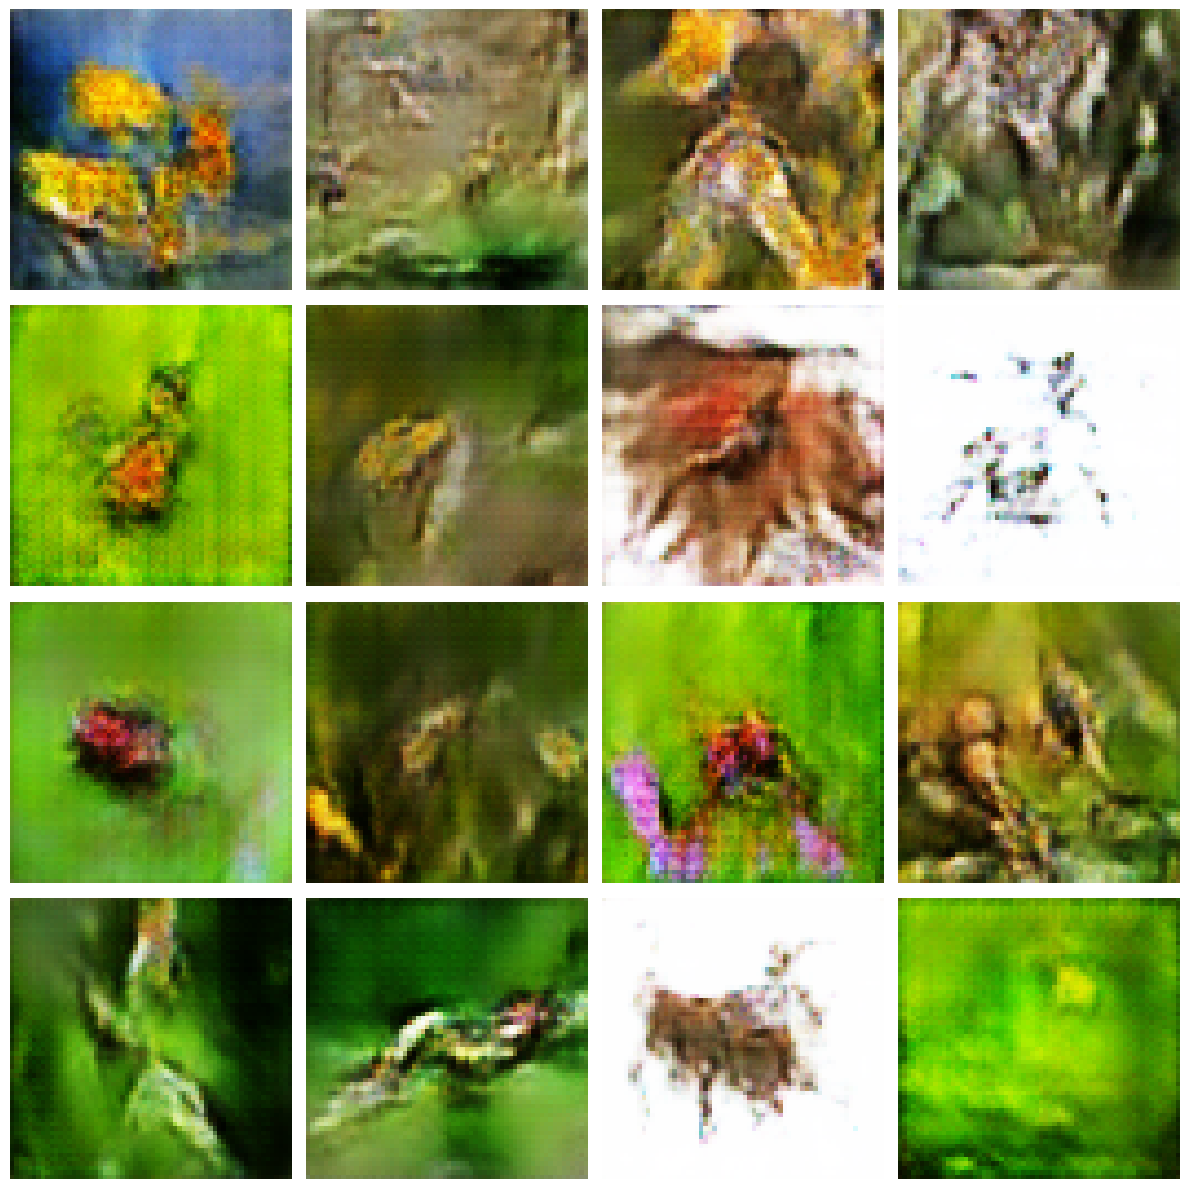

--------------------------------------------------


Epoch 96/100:   7%|▋         | 9/128 [00:02<00:24,  4.86it/s, D_loss=-3042.1470, G_loss=22693.0195, GP=58.9984]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 96/100:   9%|▉         | 12/128 [00:02<00:17,  6.78it/s, D_loss=-1298.6034, G_loss=23253.1680, GP=65.6940]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 96/100:  11%|█         | 14/128 [00:03<00:26,  4.35it/s, D_loss=-750.9792, G_loss=26332.3789, GP=37.2958] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 96/100:  28%|██▊       | 36/128 [00:06<00:14,  6.24it/s, D_loss=-981.0258,


Epoch [96/100]
  Discriminator Loss: -1739.5795
  Generator Loss: 27214.3652
--------------------------------------------------


Epoch 97/100:   5%|▍         | 6/128 [00:01<00:26,  4.53it/s, D_loss=-4418.8423, G_loss=18606.3594, GP=207.3060]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 97/100:  11%|█         | 14/128 [00:03<00:24,  4.61it/s, D_loss=-3145.7502, G_loss=25658.1133, GP=147.8578]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 97/100:  36%|███▌      | 46/128 [00:08<00:13,  6.12it/s, D_loss=-1807.3684, G_loss=27569.6680, GP=60.2682]  /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039


Epoch [97/100]
  Discriminator Loss: -2247.0850
  Generator Loss: 26686.6317
--------------------------------------------------


...


Epoch [98/100]
  Discriminator Loss: -1135.0865
  Generator Loss: 25133.9559
--------------------------------------------------


Epoch 99/100:   0%|          | 0/128 [00:00<?, ?it/s]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 99/100:   1%|          | 1/128 [00:01<02:32,  1.20s/it, D_loss=-4821.9541, G_loss=34575.7812, GP=140.4659]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 99/100:  19%|█▉        | 24/128 [00:05<00:18,  5.72it/s, D_loss=-697.4293, G_loss=24440.2422, GP=27.4536]   /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
Epoch 99/100:  54%|█████▍    | 69/128 [00:13<00:11,  5.20it/s, D_loss=-580.7366, G_loss=25151.8691, GP=37.1416] /home/2024032/oaqebl01/.local/


Epoch [99/100]
  Discriminator Loss: -1669.1300
  Generator Loss: 26040.6070
--------------------------------------------------


Epoch 100/100:  11%|█         | 14/128 [00:02<00:17,  6.37it/s, D_loss=-17065.4160, G_loss=30059.9023, GP=214.7385]/home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 100/100:  15%|█▍        | 19/128 [00:04<00:29,  3.69it/s, D_loss=-1941.2219, G_loss=30332.5684, GP=103.3719] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 100/100:  29%|██▉       | 37/128 [00:07<00:20,  4.39it/s, D_loss=-6946.1133, G_loss=16599.1445, GP=600.8608] /home/2024032/oaqebl01/.local/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 100/100:  44%|████▍     | 56/128 [00:10<00:10,  6.62it/s, D_loss


Epoch [100/100]
  Discriminator Loss: -4570.9812
  Generator Loss: 28443.0329
  Generating samples...


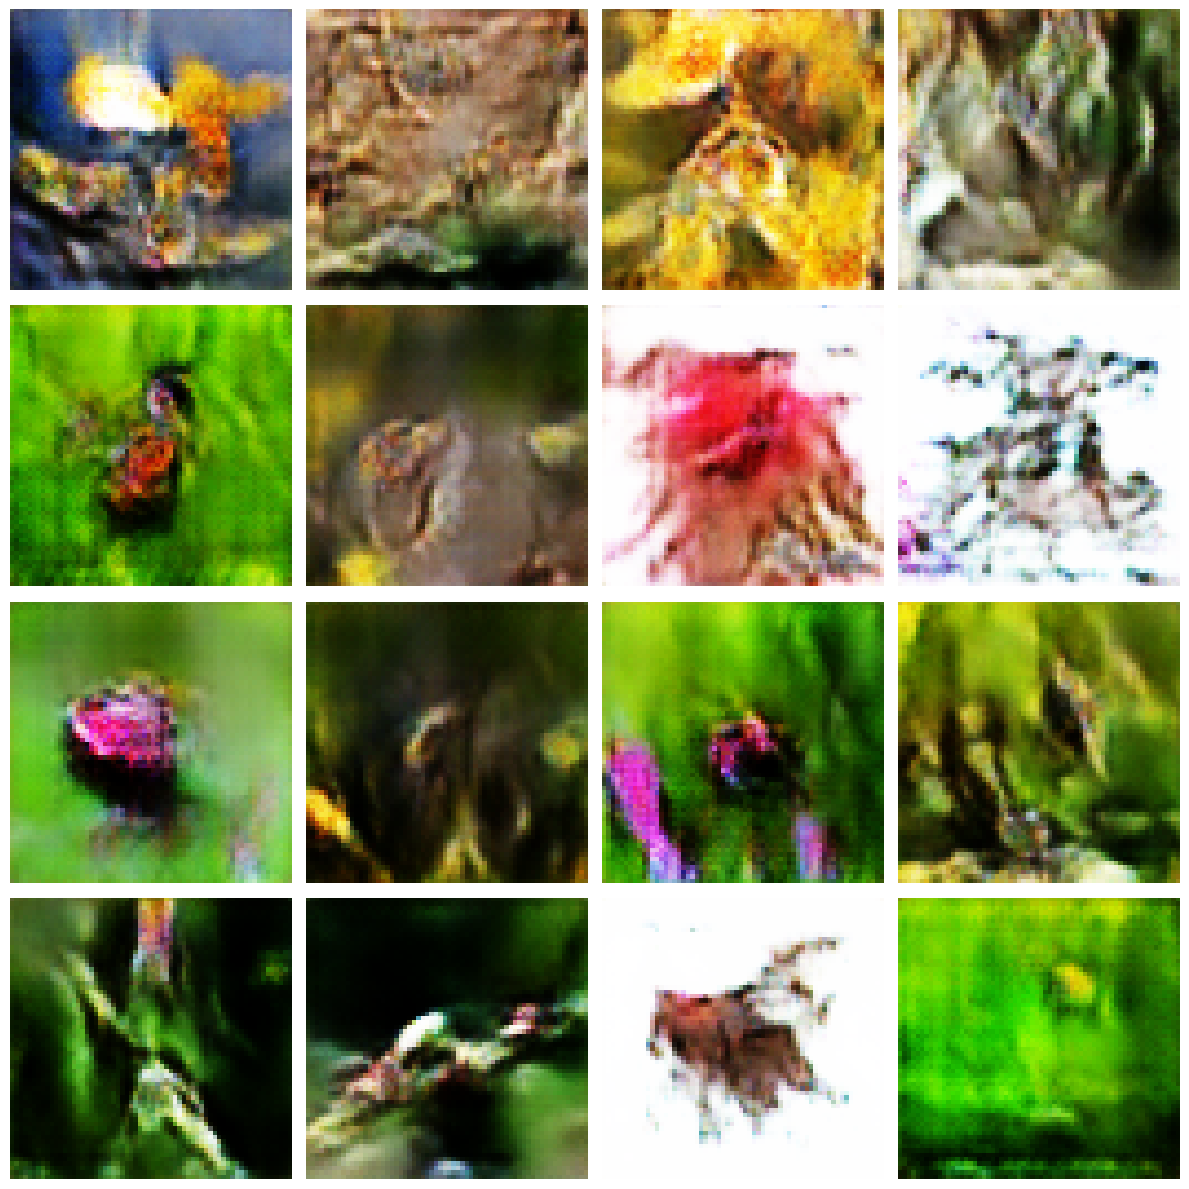

Checkpoint saved at epoch 100
--------------------------------------------------

Training completed!


In [12]:
# Main training loop
print("Starting training...")
print(f"Total epochs: {NUM_EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Discriminator updates per generator update: {N_CRITIC}")
print(f"Gradient penalty coefficient: {LAMBDA_GP}")
print(f"Device: {device}")
print("-" * 50)

for epoch in range(NUM_EPOCHS):
    epoch_D_loss = 0.0
    epoch_G_loss = 0.0
    
    # Progress bar
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    
    for batch_idx, batch_data in enumerate(pbar):
        # Handle tuple (images, labels) or just images
        if isinstance(batch_data, tuple):
            real_images, _ = batch_data  # Unpack labels (not used in training)
        else:
            real_images = batch_data
        batch_size = real_images.size(0)
        # Ensure real_images are on the correct device
        real_images = real_images.to(device, non_blocking=True)
        
        # ============================================
        # Train Discriminator (Critic)
        # ============================================
        for _ in range(N_CRITIC):
            # Zero discriminator gradients
            netD.zero_grad()
            
            # Forward pass real images
            real_output = netD(real_images)
            
            # Generate fake images - ensure noise is on device
            noise = torch.randn(batch_size, NOISE_DIM, device=device, dtype=torch.float32)
            fake_images = netG(noise)
            fake_output = netD(fake_images.detach())
            
            # Compute gradient penalty - ensure all tensors are on device
            gradient_penalty = compute_gradient_penalty(
                netD, real_images, fake_images, device
            )
            
            # Discriminator loss: E[D(fake)] - E[D(real)] + lambda * GP
            d_loss = torch.mean(fake_output) - torch.mean(real_output) + LAMBDA_GP * gradient_penalty
            
            # Backward and optimize
            d_loss.backward()
            optimizerD.step()
            
            epoch_D_loss += d_loss.item()
        
        # ============================================
        # Train Generator
        # ============================================
        netG.zero_grad()
        
        # Generate fake images - ensure noise is on device
        noise = torch.randn(batch_size, NOISE_DIM, device=device, dtype=torch.float32)
        fake_images = netG(noise)
        fake_output = netD(fake_images)
        
        # Generator loss: -E[D(fake)] (we want to maximize D(fake))
        g_loss = -torch.mean(fake_output)
        
        # Backward and optimize
        g_loss.backward()
        optimizerG.step()
        
        epoch_G_loss += g_loss.item()
        
        # Update progress bar
        pbar.set_postfix({
            'D_loss': f'{d_loss.item():.4f}',
            'G_loss': f'{g_loss.item():.4f}',
            'GP': f'{gradient_penalty.item():.4f}'
        })
    
    # Average losses for the epoch
    avg_D_loss = epoch_D_loss / (len(dataloader) * N_CRITIC)
    avg_G_loss = epoch_G_loss / len(dataloader)
    
    G_losses.append(avg_G_loss)
    D_losses.append(avg_D_loss)
    
    # Print epoch statistics
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"  Discriminator Loss: {avg_D_loss:.4f}")
    print(f"  Generator Loss: {avg_G_loss:.4f}")
    
    # Generate and save samples
    if (epoch + 1) % 5 == 0:
        print("  Generating samples...")
        generate_samples(netG, fixed_noise, num_samples=16, 
                        save_path=f'samples/epoch_{epoch+1}.png')
    
    # Save checkpoint
    if (epoch + 1) % SAVE_INTERVAL == 0:
        save_checkpoint(epoch + 1, netG, netD, optimizerG, optimizerD, 
                       (G_losses, D_losses))
    
    print("-" * 50)

print("\nTraining completed!")


## 8. Training Loss Visualization

Plot the training losses to monitor convergence. In a well-trained GAN:
- Discriminator and Generator losses should stabilize
- They don't necessarily converge to zero (unlike traditional losses)
- The key is that generated images look realistic


In [ ]:
# Plot training losses
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(G_losses, label='Generator Loss')
plt.plot(D_losses, label='Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Losses')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(G_losses, label='Generator Loss')
plt.plot(D_losses, label='Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Losses (Log Scale)')
plt.yscale('log')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_losses.png')
plt.show()


## 9. Generate Final Samples

Generate a large batch of samples to evaluate the trained model's performance.


In [ ]:
# Generate final samples
print("Generating final samples...")
final_noise = torch.randn(64, NOISE_DIM, device=device, dtype=torch.float32)
generate_samples(netG, final_noise, num_samples=64, save_path='samples/final_samples.png')


## 10. Model Architecture Summary

### Generator Architecture Details:

**Input Layer:**
- Fully connected: 100 → 8192 (4×4×512)
- Reshape to: (batch, 512, 4, 4)

**Transposed Convolutional Layers:**
1. ConvTranspose2d(512, 256, kernel=4, stride=2, padding=1) + BN + ReLU
   - Output: (batch, 256, 8, 8)
2. ConvTranspose2d(256, 128, kernel=4, stride=2, padding=1) + BN + ReLU
   - Output: (batch, 128, 16, 16)
3. ConvTranspose2d(128, 64, kernel=4, stride=2, padding=1) + BN + ReLU
   - Output: (batch, 64, 32, 32)
4. ConvTranspose2d(64, 3, kernel=4, stride=2, padding=1) + Tanh
   - Output: (batch, 3, 64, 64)

### Discriminator Architecture Details:

**Convolutional Layers:**
1. Conv2d(3, 64, kernel=4, stride=2, padding=1) + LeakyReLU(0.2)
   - Output: (batch, 64, 32, 32)
2. Conv2d(64, 128, kernel=4, stride=2, padding=1) + BN + LeakyReLU(0.2)
   - Output: (batch, 128, 16, 16)
3. Conv2d(128, 256, kernel=4, stride=2, padding=1) + BN + LeakyReLU(0.2)
   - Output: (batch, 256, 8, 8)
4. Conv2d(256, 512, kernel=4, stride=2, padding=1) + BN + LeakyReLU(0.2)
   - Output: (batch, 512, 4, 4)
5. Conv2d(512, 1, kernel=4, stride=1, padding=0)
   - Output: (batch, 1, 1, 1) → flattened to (batch, 1)

## Key Equations Recap

### Transposed Convolution Output Size:
$$H_{out} = (H_{in} - 1) \times s - 2p + k$$

### Regular Convolution Output Size:
$$H_{out} = \lfloor \frac{H_{in} + 2p - k}{s} \rfloor + 1$$

### WGAN-GP Loss:
$$L_D = \mathbb{E}[D(G(z))] - \mathbb{E}[D(x)] + \lambda \mathbb{E}[(\|\nabla_{\hat{x}} D(\hat{x})\|_2 - 1)^2]$$
$$L_G = -\mathbb{E}[D(G(z))]$$

Where:
- $x$: real samples
- $G(z)$: generated samples
- $\hat{x} = \epsilon x + (1-\epsilon)G(z)$: interpolated samples
- $\lambda = 10$: gradient penalty coefficient


## 11. Loading Saved Models

Use this cell to load a previously saved checkpoint and continue training or generate samples.


In [ ]:
def load_checkpoint(checkpoint_path, netG, netD, optimizerG, optimizerD):
    """Load model from checkpoint"""
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    netG.load_state_dict(checkpoint['netG_state_dict'])
    netD.load_state_dict(checkpoint['netD_state_dict'])
    optimizerG.load_state_dict(checkpoint['optimizerG_state_dict'])
    optimizerD.load_state_dict(checkpoint['optimizerD_state_dict'])
    
    epoch = checkpoint['epoch']
    G_losses = checkpoint['G_losses']
    D_losses = checkpoint['D_losses']
    
    print(f"Checkpoint loaded from epoch {epoch}")
    return epoch, G_losses, D_losses

# Example usage (uncomment to load a checkpoint):
# epoch, G_losses, D_losses = load_checkpoint(
#     'checkpoints/checkpoint_epoch_50.pth',
#     netG, netD, optimizerG, optimizerD
# )


## 12. Interactive Sample Generation

Generate custom samples by providing your own noise vectors or random seeds.


In [ ]:
def generate_custom_samples(netG, num_samples=16, seed=None):
    """Generate samples with optional seed for reproducibility"""
    # Get device from model
    model_device = next(netG.parameters()).device
    
    if seed is not None:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        np.random.seed(seed)
    
    # Ensure noise is on the same device as the model
    noise = torch.randn(num_samples, NOISE_DIM, device=model_device, dtype=torch.float32)
    generate_samples(netG, noise, num_samples=num_samples)

# Generate samples with a specific seed
print("Generating samples with seed=42:")
generate_custom_samples(netG, num_samples=16, seed=42)

# Generate random samples
print("\nGenerating random samples:")
generate_custom_samples(netG, num_samples=16, seed=None)
